# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

Я заранее извиняюсь всеми старыми и новыми богами, за код, который вы увидите в этом ноутбуке, мне искренне жаль, что так вышло...
Я пытался сделать красиво - не получилось.

In [1]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'retina'

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#7298ce">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #d18753; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#d18753">**выборы**</font> и подбирать <font color="#d18753">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [2]:
df_test = pd.read_csv("data/matches_df_test.csv")
df_train = pd.read_csv("data/matches_df_train.csv")
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 641090 entries, 0 to 641089
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   match_id     641090 non-null  int64  
 1   date         641090 non-null  str    
 2   region       641090 non-null  str    
 3   game_mode    641090 non-null  int64  
 4   duration     641090 non-null  int64  
 5   radiant_win  641090 non-null  bool   
 6   avg_mmr      472334 non-null  float64
dtypes: bool(1), float64(1), int64(3), str(2)
memory usage: 30.0 MB


In [3]:
df_train.describe()

,match_id,game_mode,duration,avg_mmr
count,641090.000000,641090.000000,641090.000000,472334.000000
mean,383791.138898,9.472508,2544.662008,3133.928477
std,221701.444546,9.954080,720.510457,1759.367566
min,1.000000,1.000000,0.000000,243.700000
25%,191835.250000,1.000000,2070.000000,1677.400000
50%,383788.500000,2.000000,2499.000000,2846.850000
75%,575786.750000,22.000000,2986.000000,4428.975000
max,767821.000000,22.000000,14979.000000,7065.400000


In [4]:
df_train.head(3)

,match_id,date,region,game_mode,duration,radiant_win,avg_mmr
0,1,2024-02-12,Europe West,4,2625,False,3519.7
1,2,2024-04-08,South Africa,2,7526,True,2330.9
2,3,2024-06-16,SE Asia,1,2831,True,1579.6


In [5]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 59748 entries, 0 to 59747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   match_id   59748 non-null  int64  
 1   date       59748 non-null  str    
 2   region     59748 non-null  str    
 3   game_mode  59748 non-null  int64  
 4   avg_mmr    44504 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.3 MB


In [6]:
df_test.describe()

,match_id,game_mode,avg_mmr
count,59748.000000,59748.000000,44504.000000
mean,384800.993640,9.543165,3155.675807
std,221347.789271,9.967703,1926.963244
min,8.000000,1.000000,265.000000
25%,192927.000000,1.000000,1551.675000
50%,385881.500000,2.000000,2778.750000
75%,575798.000000,22.000000,4535.650000
max,767816.000000,22.000000,7680.600000


In [7]:
df_test.head(3)

,match_id,date,region,game_mode,avg_mmr
0,8,2024-12-01,China,1,2305.0
1,29,2024-12-17,Europe West,22,NaN
2,34,2024-12-19,Europe West,22,2278.5


In [8]:
df_train.shape, df_test.shape

((641090, 7), (59748, 5))

Воу, тренировочный датасет $30$Мб...

Что за непорядок, почему в тестовом датафрейме нет признака duration.

Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

<Figure size 900x500 with 0 Axes>

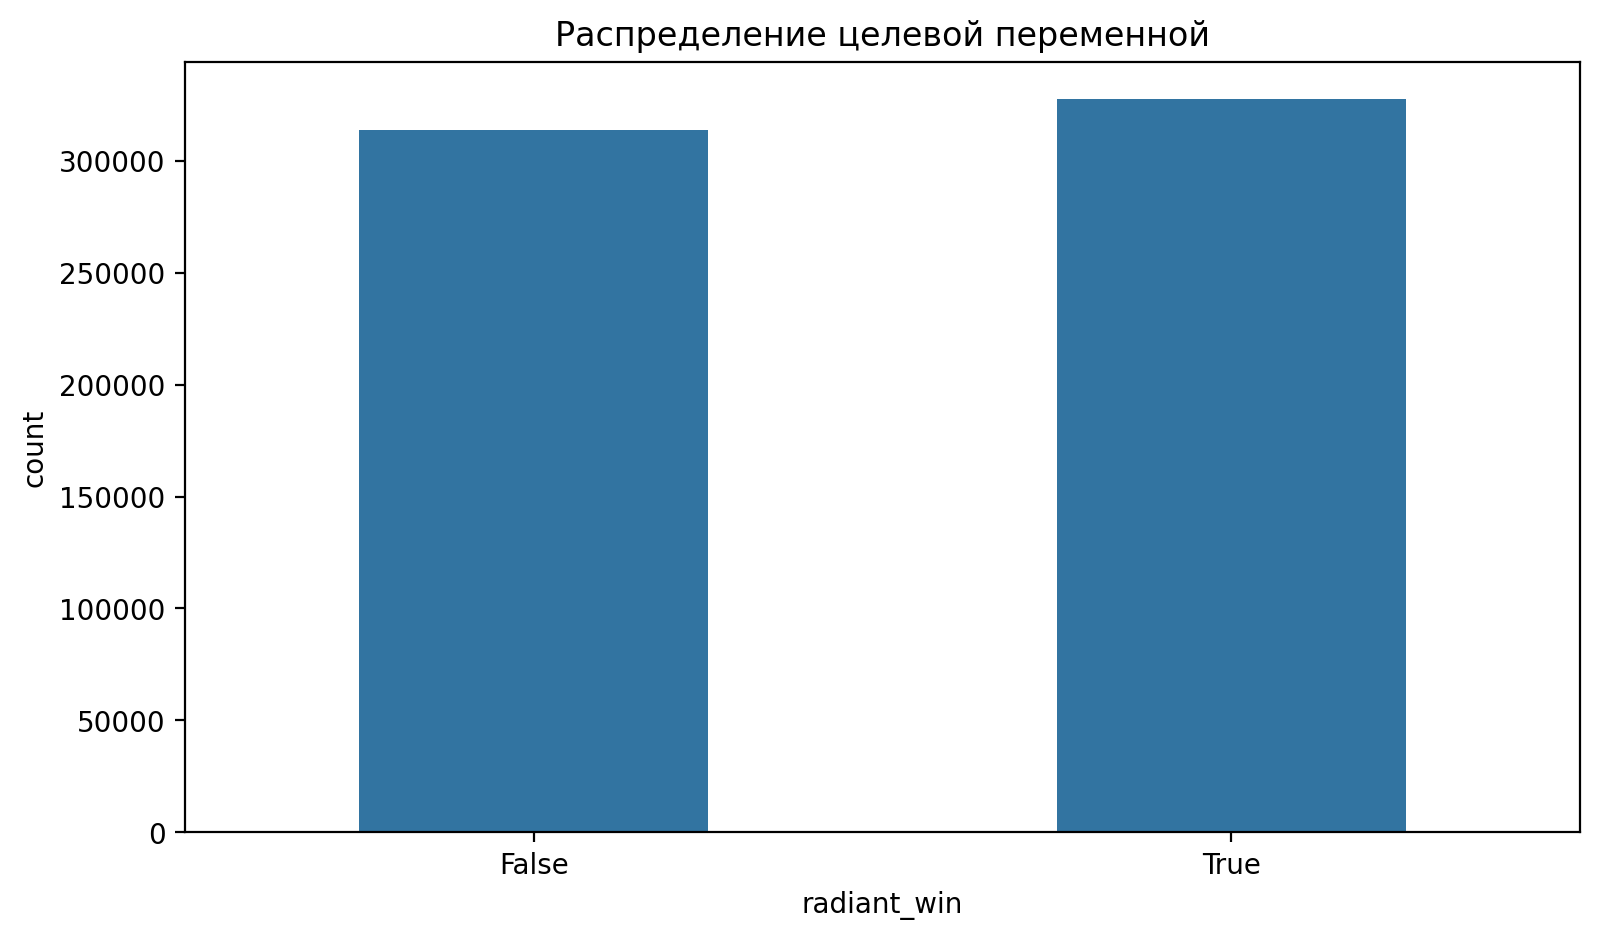

In [9]:
plt.figure(figsize=(9, 5))

plt.figure(figsize=(9, 5))
sns.countplot(x='radiant_win', data=df_train, width=0.5)
plt.title("Распределение целевой переменной")
plt.show();

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:**
Если мне не изменяет память, то в нашем случае нам более подходящая метрика $\text{Gini}$, потому что у нас нет дисбаланса классов, а $\text{AUC-PR}$ используется, когда у нас довольно большой дисбаланс классов.
</div> 


#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше


</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

Это кстати нерфанули уже, больше нет преимущества, кемпы перенесли.

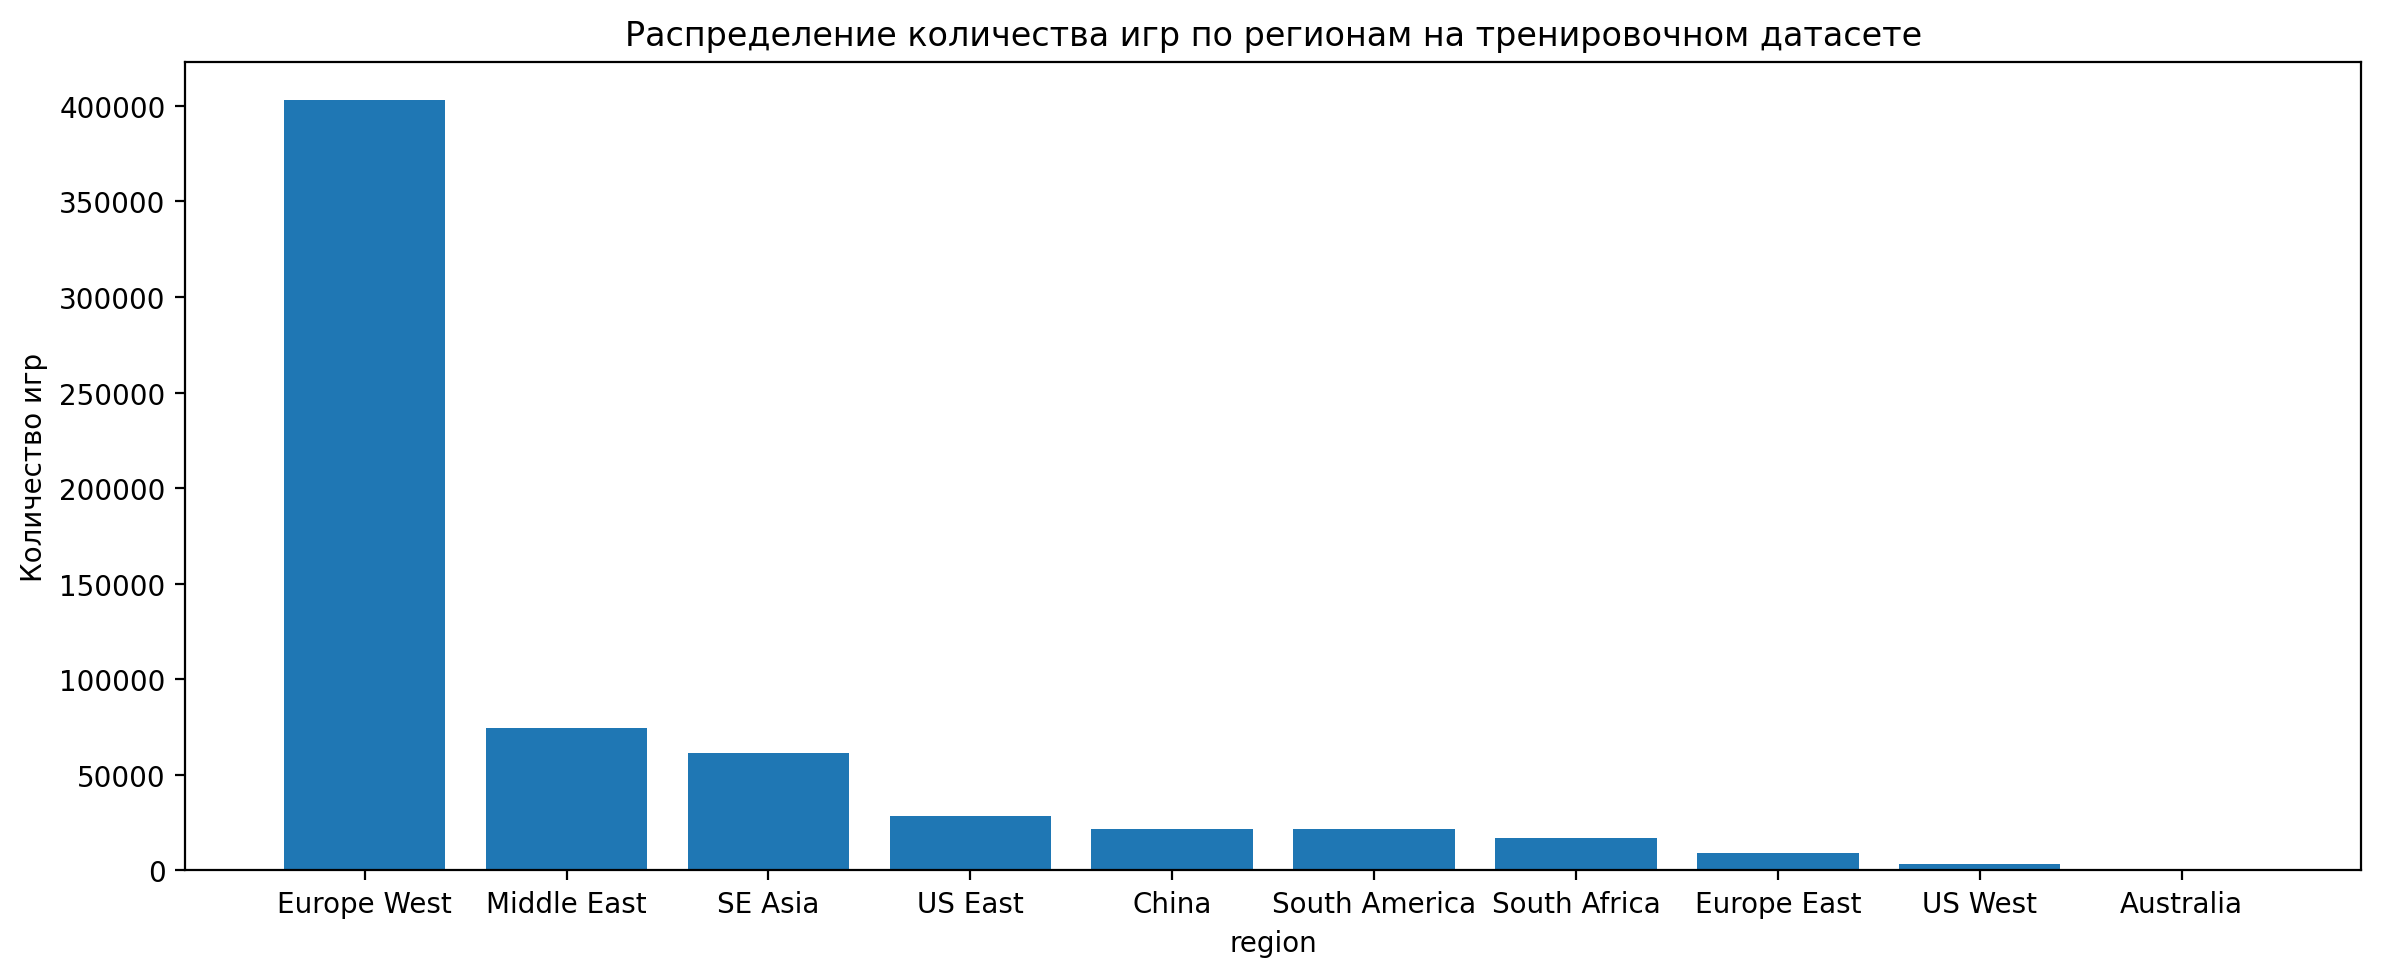

In [10]:
plt.figure(figsize=(12,5))

region_train = df_train["region"].value_counts()
plt.bar(region_train.index, region_train.values)
plt.title("Распределение количества игр по регионам на тренировочном датасете")
plt.xlabel("region")
plt.ylabel("Количество игр")
plt.tight_layout()
plt.show();

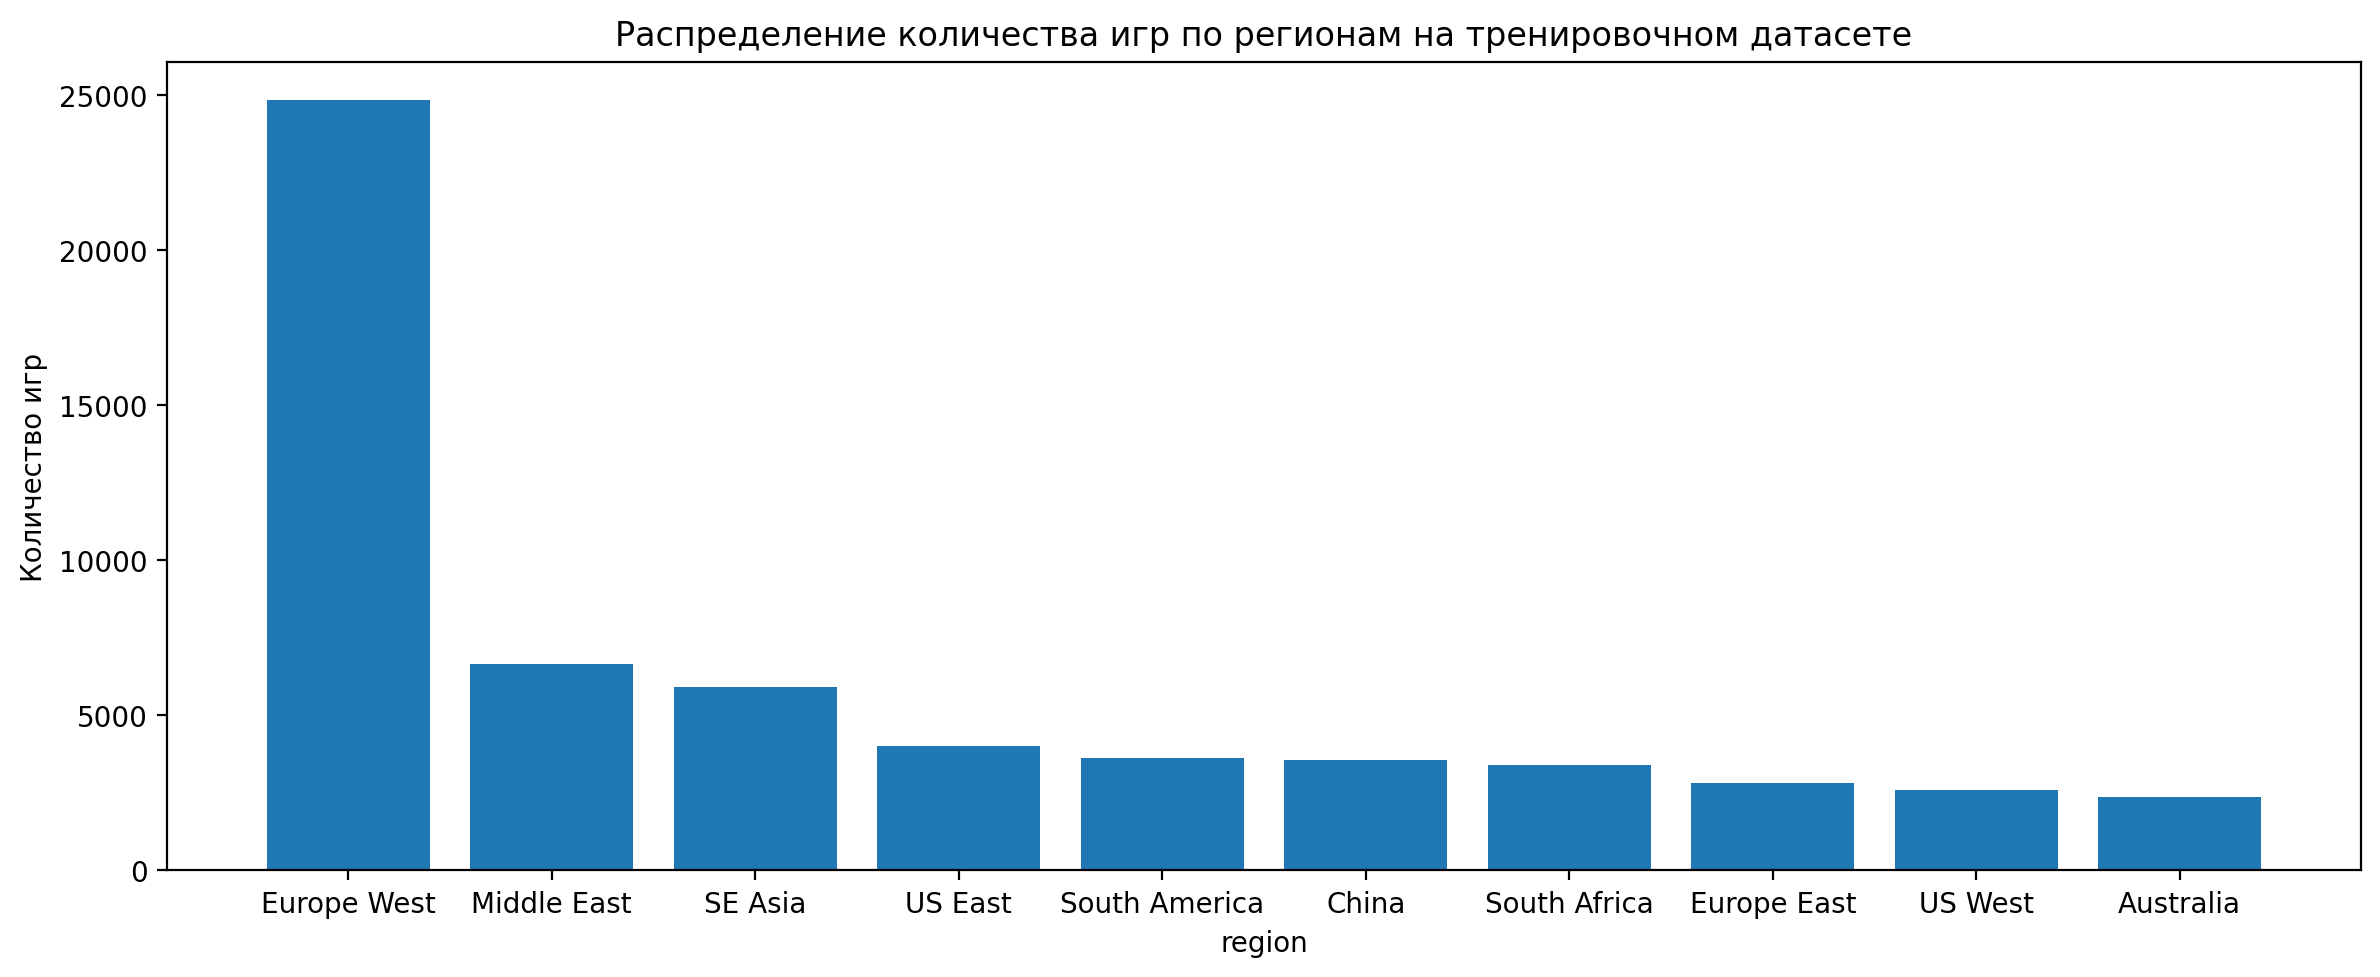

In [11]:
plt.figure(figsize=(12,5))

region_test = df_test["region"].value_counts()
plt.bar(region_test.index, region_test.values)
plt.title("Распределение количества игр по регионам на тренировочном датасете")
plt.xlabel("region")
plt.ylabel("Количество игр")
plt.tight_layout()
plt.show();

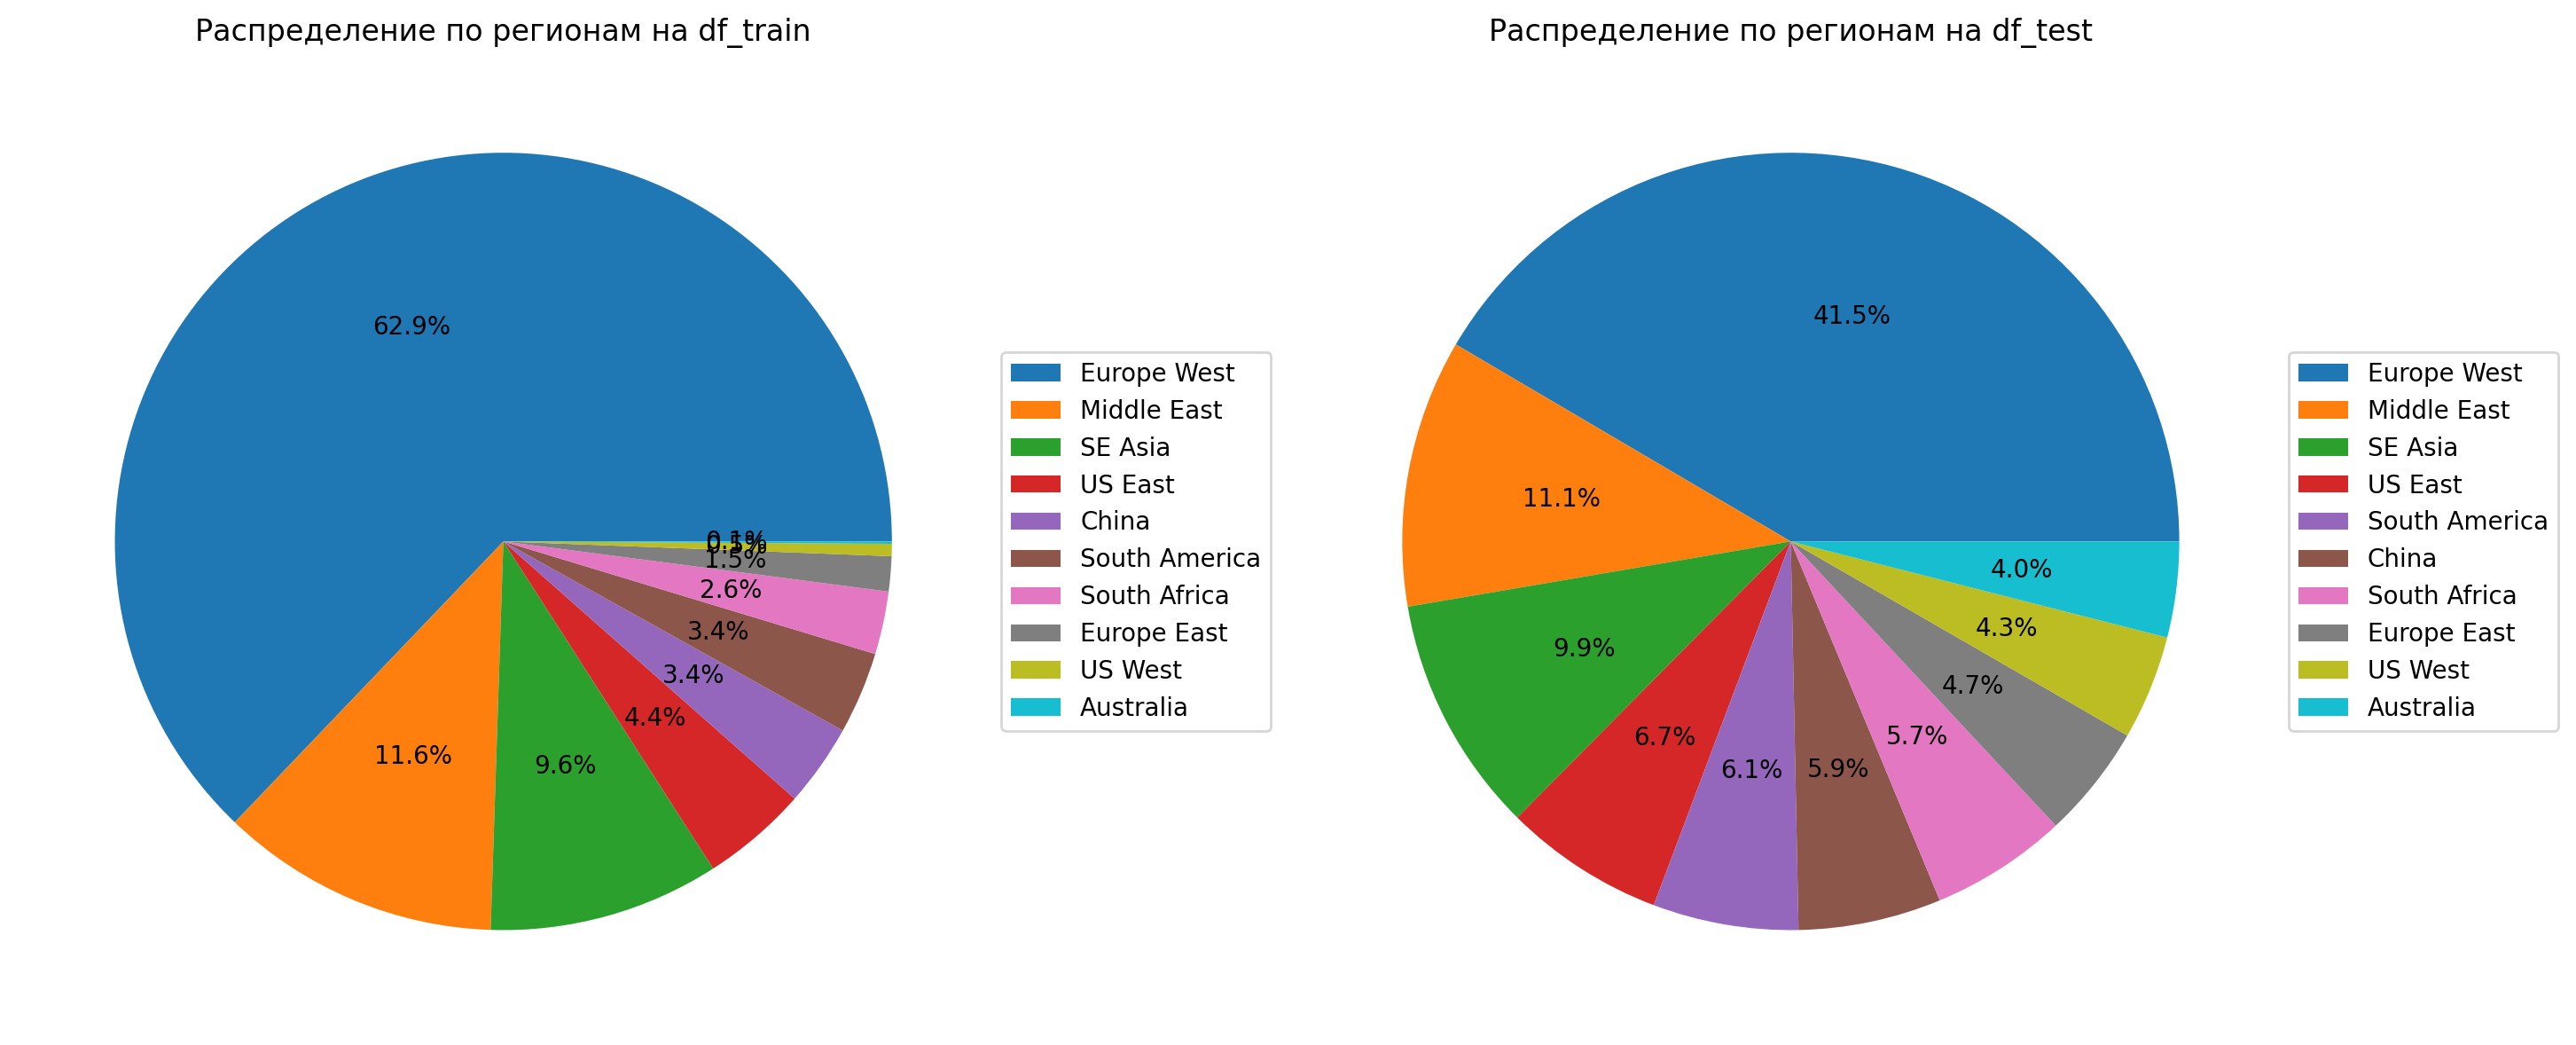

In [12]:
region_train = df_train["region"].value_counts()
region_test = df_test["region"].value_counts()


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


axes[0].pie(region_train.values, autopct='%1.1f%%')
axes[0].set_title("Распределение по регионам на df_train")
axes[0].legend(labels=region_train.index.astype(str), 
               loc="center left", 
               bbox_to_anchor=(1, 0.5))


axes[1].pie(region_test.values, autopct='%1.1f%%')
axes[1].set_title("Распределение по регионам на df_test")
axes[1].legend(labels=region_test.index.astype(str), 
               loc="center left", 
               bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

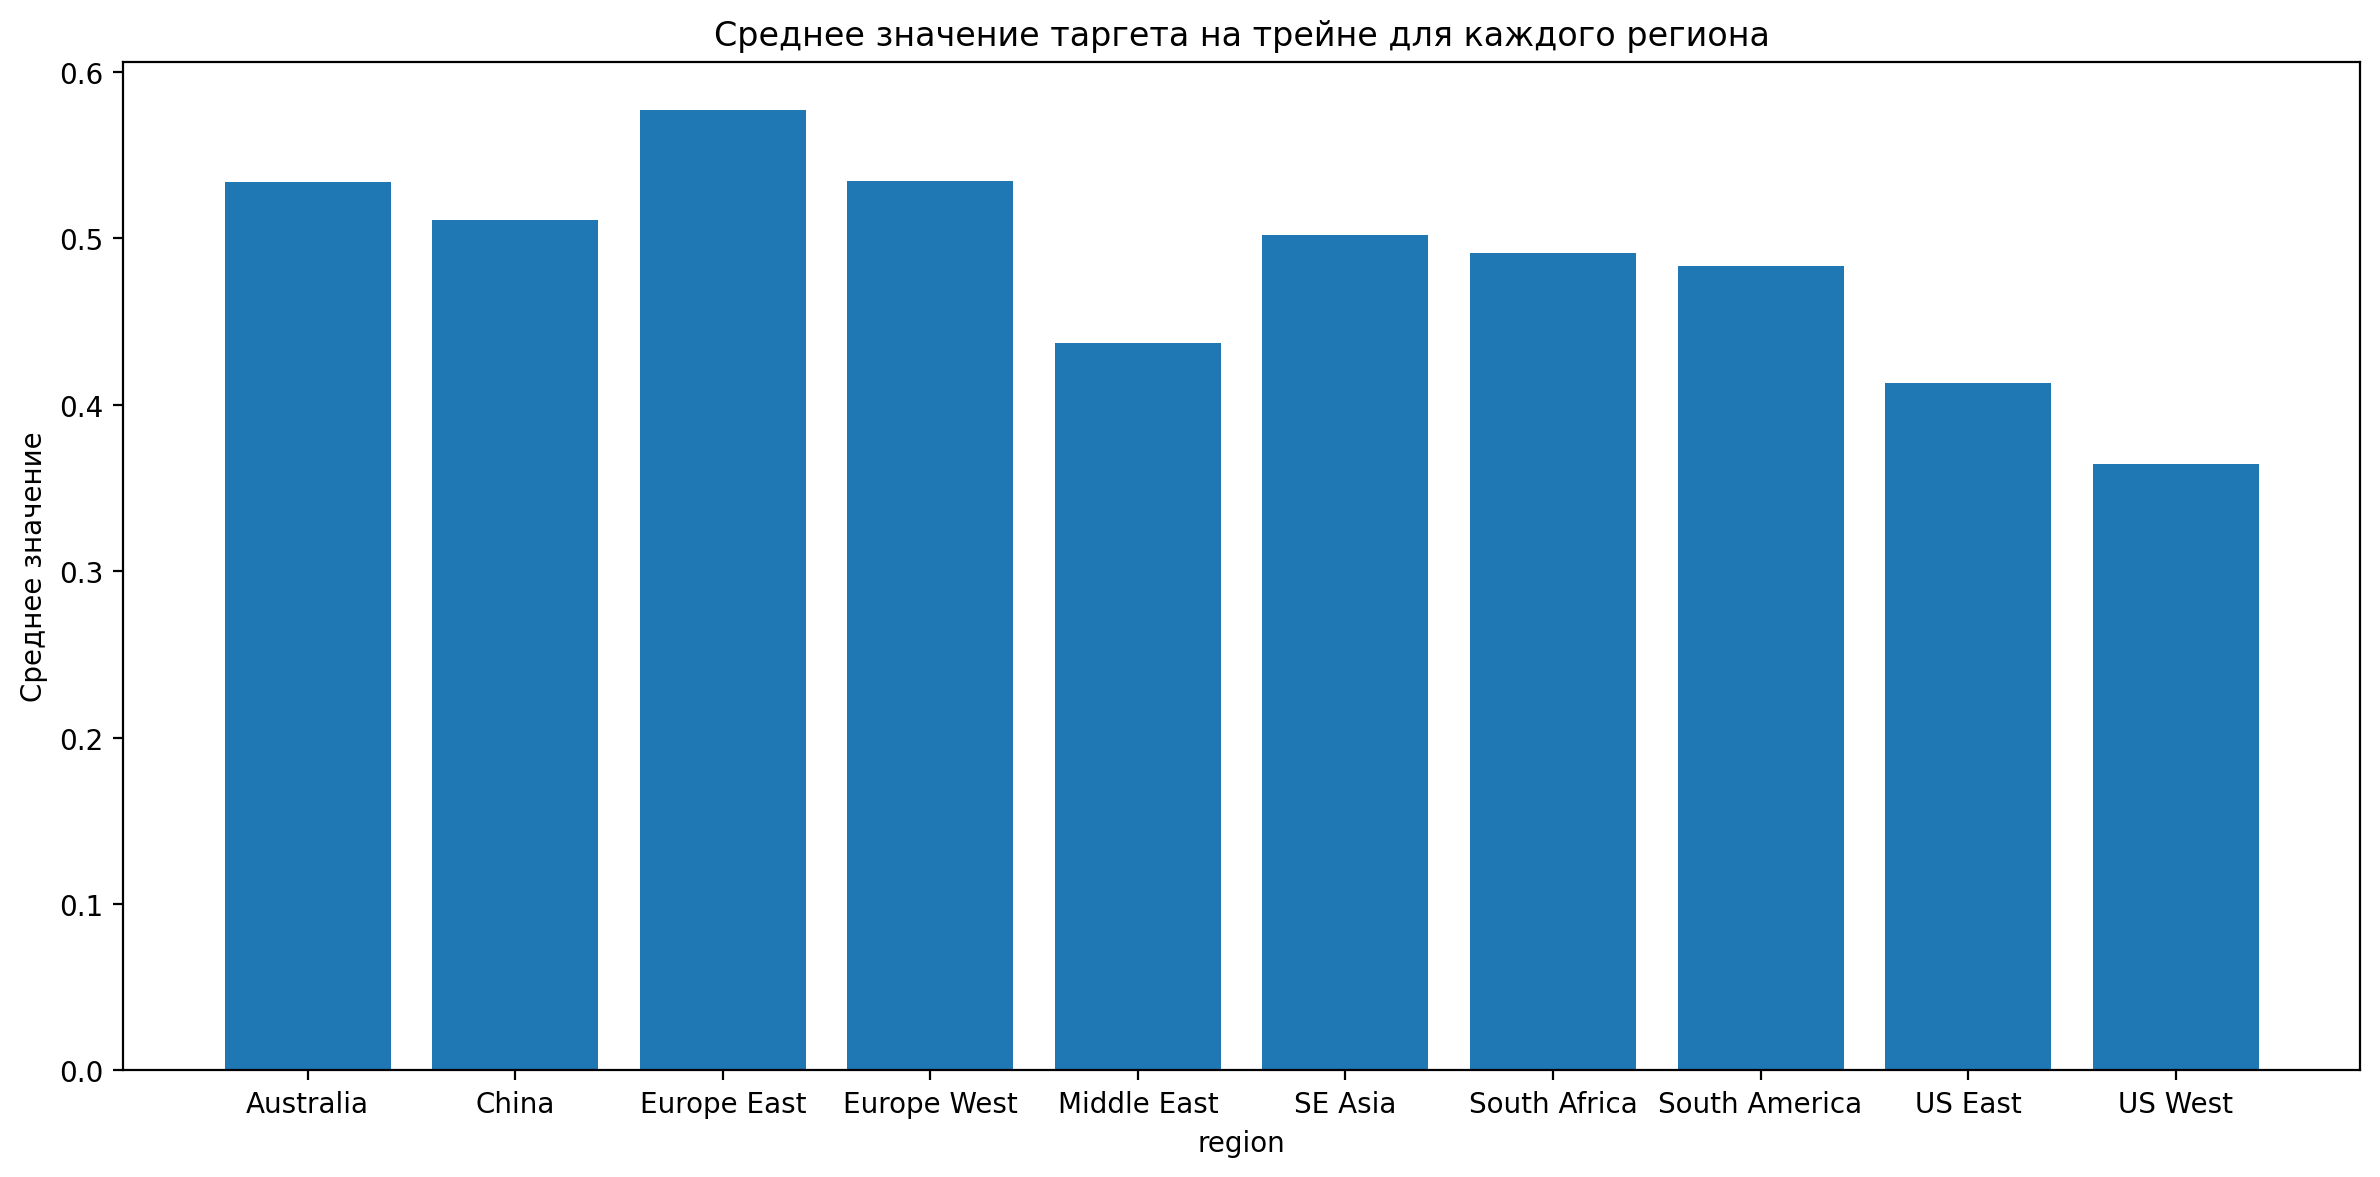

In [13]:
region_win = df_train.groupby(["region"])["radiant_win"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.bar(region_win["region"], region_win["radiant_win"])
plt.title("Среднее значение таргета на трейне для каждого региона")
plt.ylabel("Среднее значение")
plt.xlabel("region")
plt.tight_layout()
plt.show();

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:**  Распределение регионов в обоих датасетах неравномерное, соответсвенно, когда мы разобьем при помощи энкодера на разные признаки, у регионов с маленьким количеством игр будут меньшие веса в модели. Если мы говорим о обучении модели, где таргетом выступает регион, то скорее всего модель получится плохой из-за дисбаланса этого признака, потому что мажоритарный класс $\text{Europe West}$ занимает аж 62 процента тренировочной выборки.

А на тестовой выборке все выглядит намного лучше, распределение приблизилось к равномерному, если не брать мажоритарный класс.
</div>

Наша первая развилка — <font color="#d18753">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#d18753">**One-Hot Encoder**</font> | <font color="#d18753">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">
Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 
</div>

In [14]:
!pip install -qU category-encoders
import category_encoders as ce

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:** Так как у нас мало классов в признаке $\text{region}$, то я бы выбрал $\text{OHE}$, потому что использовать $\text{Target Encoder}$ довольно опасно из-за утечки таргета, ну и обычно используется, когда у нас очень много классов в признаке.
</div>

Закодируйте колонку `region` выбранным вами способом

In [15]:
encoder = ce.OneHotEncoder(use_cat_names=True)
region_train = encoder.fit_transform(df_train["region"])
region_test = encoder.transform(df_test["region"])

df_train = pd.concat([df_train.drop("region", axis=1).reset_index(drop=True), region_train.reset_index(drop=True)], axis=1)
df_test = pd.concat([df_test.drop("region", axis=1).reset_index(drop=True), region_test.reset_index(drop=True)], axis=1)

In [16]:
df_train.head(3)

,match_id,date,game_mode,duration,radiant_win,avg_mmr,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,region_Australia
0,1,2024-02-12,4,2625,False,3519.7,1,0,0,0,0,0,0,0,0,0
1,2,2024-04-08,2,7526,True,2330.9,0,1,0,0,0,0,0,0,0,0
2,3,2024-06-16,1,2831,True,1579.6,0,0,1,0,0,0,0,0,0,0


In [17]:
df_test.head(3)

,match_id,date,game_mode,avg_mmr,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,region_Australia
0,8,2024-12-01,1,2305.0,0,0,0,0,0,0,0,1,0,0
1,29,2024-12-17,22,NaN,1,0,0,0,0,0,0,0,0,0
2,34,2024-12-19,22,2278.5,1,0,0,0,0,0,0,0,0,0


#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

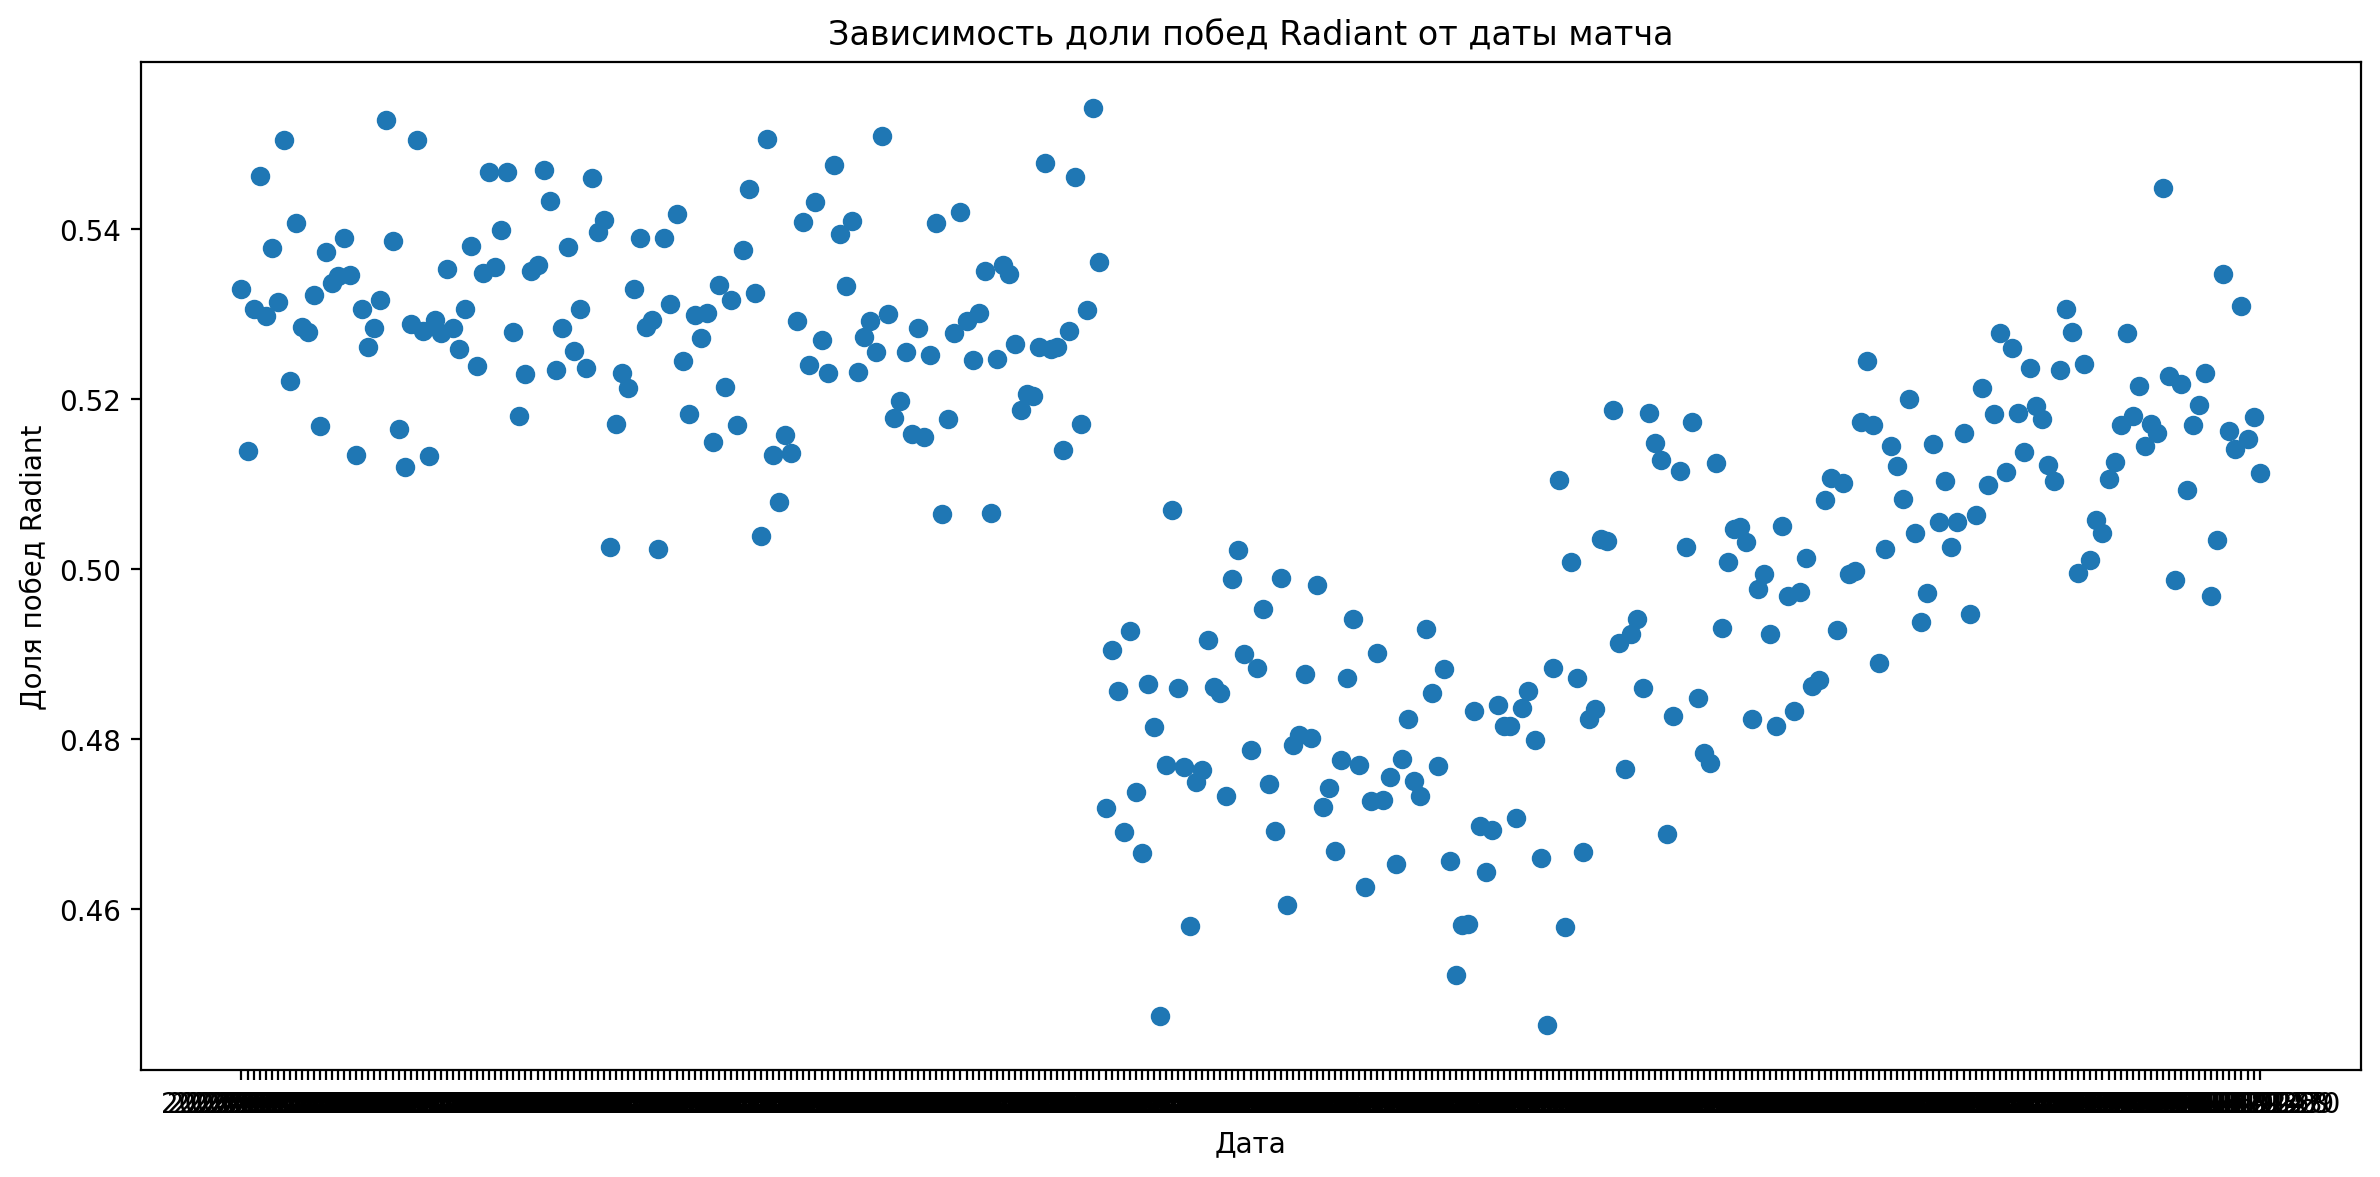

In [18]:
rad_win_date = df_train.groupby("date")["radiant_win"].mean().reset_index()
plt.figure(figsize=(12, 6))
plt.scatter(rad_win_date["date"], rad_win_date["radiant_win"])
plt.title("Зависимость доли побед Radiant от даты матча")
plt.ylabel("Доля побед Radiant")
plt.xlabel("Дата")
plt.tight_layout()
plt.show();

In [19]:
rad_win_date[rad_win_date["radiant_win"] < 0.47]

,date,radiant_win
146,2024-05-26,0.469075
149,2024-05-29,0.466630
152,2024-06-01,0.447398
157,2024-06-06,0.458011
171,2024-06-20,0.469200
173,2024-06-22,0.460526
181,2024-06-30,0.466889
186,2024-07-05,0.462612
191,2024-07-10,0.465278
200,2024-07-19,0.465706


In [20]:
print(f"Старт: {df_train["date"].min()}, Конец: {df_train["date"].max()}")
print(f"Старт: {df_test["date"].min()}, Конец: {df_test["date"].max()}")

Старт: 2024-01-01, Конец: 2024-11-30
Старт: 2024-12-01, Конец: 2024-12-31


В тестовом датасете только информация об играх за декабрь 2024 года, а в тренировочном информация об играх за весь 2024 год до декабря. Что логично, ведь нельзя чтобы мы обучались на данных после тестовых данных.

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:** Ну скорее всего выпустили патч, который как раз фиксит неравность кэмпов на карте, в следствии чего доля побед сильно упала. Или просто из-за патча.

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#d18753">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#d18753">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:**  Ну в нашем случае это скорее всего даст буст, потому что если мы закодируем день недели, то например логично, что выходные дни недели дадут больший вклад в модель и будут полезными признаками, еще можно закодировать день месяца, потому что обычно в начале месяца в доте выходят патчи, что тоже положительно повлияет на модель. Еще можно ввести доп бинарный признак выходной или нет. По хорошему также наверное ввести признак $\text{Количество дней с последнего патча}$, но тут нужна информация о патчах, ее как раз можно подцепить из интернета, потому что наша игра $ \text{still beta}$ и  патчи не такие частые, она важна потому что мы видели зависимость выхода патча и доли побед таргета. 

Дни месяца и дни недели закодируем циклическим преобразованием(жестко начитался в интернете), так как они периодические просто используем $\text{sin}$ и $\text{cos}$.

Месяцы не будем кодировать, потому что в тесте только 1 месяц и он просто будет всегда костантой для модели.

</div>

3. Закодируйте новые признаки, согласно вашему ответу

Для начала надо привести признак $\text{date}$ к приличному виду.

In [21]:
from sklearn.preprocessing import StandardScaler

def day_since_patch(date):
    past_patch = dota_patch[dota_patch <= date]
    if len(past_patch) == 0:
        return 0
    return (date - past_patch[-1]).days

def cyclic_encode(df, col, max_val, round_dig=6):
    df[f"{col}_sin"] = np.round(np.sin(2 * np.pi * df[col]/max_val), round_dig)
    df[f"{col}_cos"] = np.round(np.cos(2 * np.pi * df[col]/max_val), round_dig)
    return df


dota_patch = pd.to_datetime(["2024-02-22", "2024-05-22", "2024-08-01"])


In [22]:
df_train["date"] = pd.to_datetime(df_train["date"])
df_test["date"] = pd.to_datetime(df_test["date"])

for df in [df_train, df_test]:
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)



for df in [df_train, df_test]:
    df["days_last_patch"] = df["date"].apply(day_since_patch)

df_train = cyclic_encode(df_train, "day", 31)
df_train = cyclic_encode(df_train, "day_of_week", 7)

df_test = cyclic_encode(df_test, "day", 31)
df_test = cyclic_encode(df_test, "day_of_week", 7)

scaler = StandardScaler()
df_train["days_last_patch"] = scaler.fit_transform(df_train[["days_last_patch"]])
df_test["days_last_patch"] = scaler.transform(df_test[["days_last_patch"]])

In [23]:
df_train[df_train["day_sin"] == 0].head(3)

,match_id,date,game_mode,duration,radiant_win,avg_mmr,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,...,region_US West,region_Australia,day,day_of_week,is_weekend,days_last_patch,day_sin,day_cos,day_of_week_sin,day_of_week_cos
4,5,2024-03-31,22,2051,True,NaN,0,1,0,0,...,0,0,31,6,1,-0.103861,-0.0,1.0,-0.781831,0.623490
177,205,2024-01-31,1,3301,True,NaN,0,0,0,0,...,0,0,31,2,0,-1.223418,-0.0,1.0,0.974928,-0.222521
268,320,2024-01-31,3,2293,True,NaN,1,0,0,0,...,0,0,31,2,0,-1.223418,-0.0,1.0,0.974928,-0.222521


Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** Ну потому что у нас может случится утечка будущего в прошлое, ну если у нас на трейне будет дата с августа, а в валидации с мая, модель будет неправильно работать.

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#d18753">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#d18753">**трешхолд**</font> `t` или <font color="#d18753">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [24]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.base import clone


def CV_OOT(model, feature_cols, n_splits=7):
    df_sorted = df_train.sort_values("date").reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=len(df_sorted)//10)
    scores = []

    for train_indx, val_indx in tscv.split(df_sorted):
        X_train = df_sorted.iloc[train_indx][feature_cols]
        y_train = df_sorted.iloc[train_indx]["radiant_win"]

        X_val = df_sorted.iloc[val_indx][feature_cols]
        y_val = df_sorted.iloc[val_indx]["radiant_win"]
        model_fold = clone(model)

        model_fold.fit(X_train, y_train)
        y_pred = model_fold.predict_proba(X_val)[:, 1]
        scores.append(gini(y_val, y_pred))
    return np.mean(scores), scores

И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#d18753">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#d18753"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#d18753"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#d18753"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#d18753"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#d18753">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#d18753">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#d18753">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но небольшой буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [25]:
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression



data_features = ["day", "day_of_week", "is_weekend", "days_last_patch", "day_sin", "day_cos", "day_of_week_sin", "day_of_week_cos"]
region_features = ["region_Europe West", "region_South Africa", "region_SE Asia", "region_Middle East", "region_US East",
                   "region_Europe East", "region_South America", "region_China", "region_US West", "region_Australia"]

data_region_features = data_features + region_features

gini_sgd_score = []
gini_log_score = []

for cols in [data_features, region_features, data_region_features]:

    sgd_mean, sgd_scores = CV_OOT(SGDClassifier(loss="log_loss", max_iter=10000, penalty="elasticnet", l1_ratio=0.2), cols)
    log_mean, log_scores = CV_OOT(LogisticRegression(max_iter=10000, tol=1e-3), cols)
    
    print(f"SGD mean Gini: {sgd_mean:.4f}")
    print(f"LogReg mean Gini: {log_mean:.4f}\n")


SGD mean Gini: 0.0029
LogReg mean Gini: 0.0030

SGD mean Gini: 0.0761
LogReg mean Gini: 0.0723

SGD mean Gini: 0.0762
LogReg mean Gini: 0.0772



<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:** Судя по обоим моделям, даты вообще никак не помогли и лучше бы их удалить, чтобы не расширять признаковое пространство. Ну я держал некоторую надежду на даты, потому что по хорошему они судя про графику вляют на таргет.

Оставим только два, на которые я поставлю хату, что они влияют, $\text{is weekend}$ и $\text{days last patch}$

</div>

In [26]:
df_train = df_train.drop(columns=["day", "day_of_week", "day_sin", "day_cos", "day_of_week_sin", "day_of_week_cos"])
df_test = df_test.drop(columns=["day", "day_of_week", "day_sin", "day_cos", "day_of_week_sin", "day_of_week_cos"])

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

Я уже жалею, что выбрал CV OOT, потому что нет фиксированного датасета, наверное надо было делать просто OOT...

In [27]:
df_sorted = df_train.sort_values("date")
t = df_sorted["date"].quantile(0.8)
df_train_oot = df_sorted[df_sorted["date"] < t]
df_val_oot = df_sorted[df_sorted["date"] >= t]

<Figure size 1200x600 with 0 Axes>

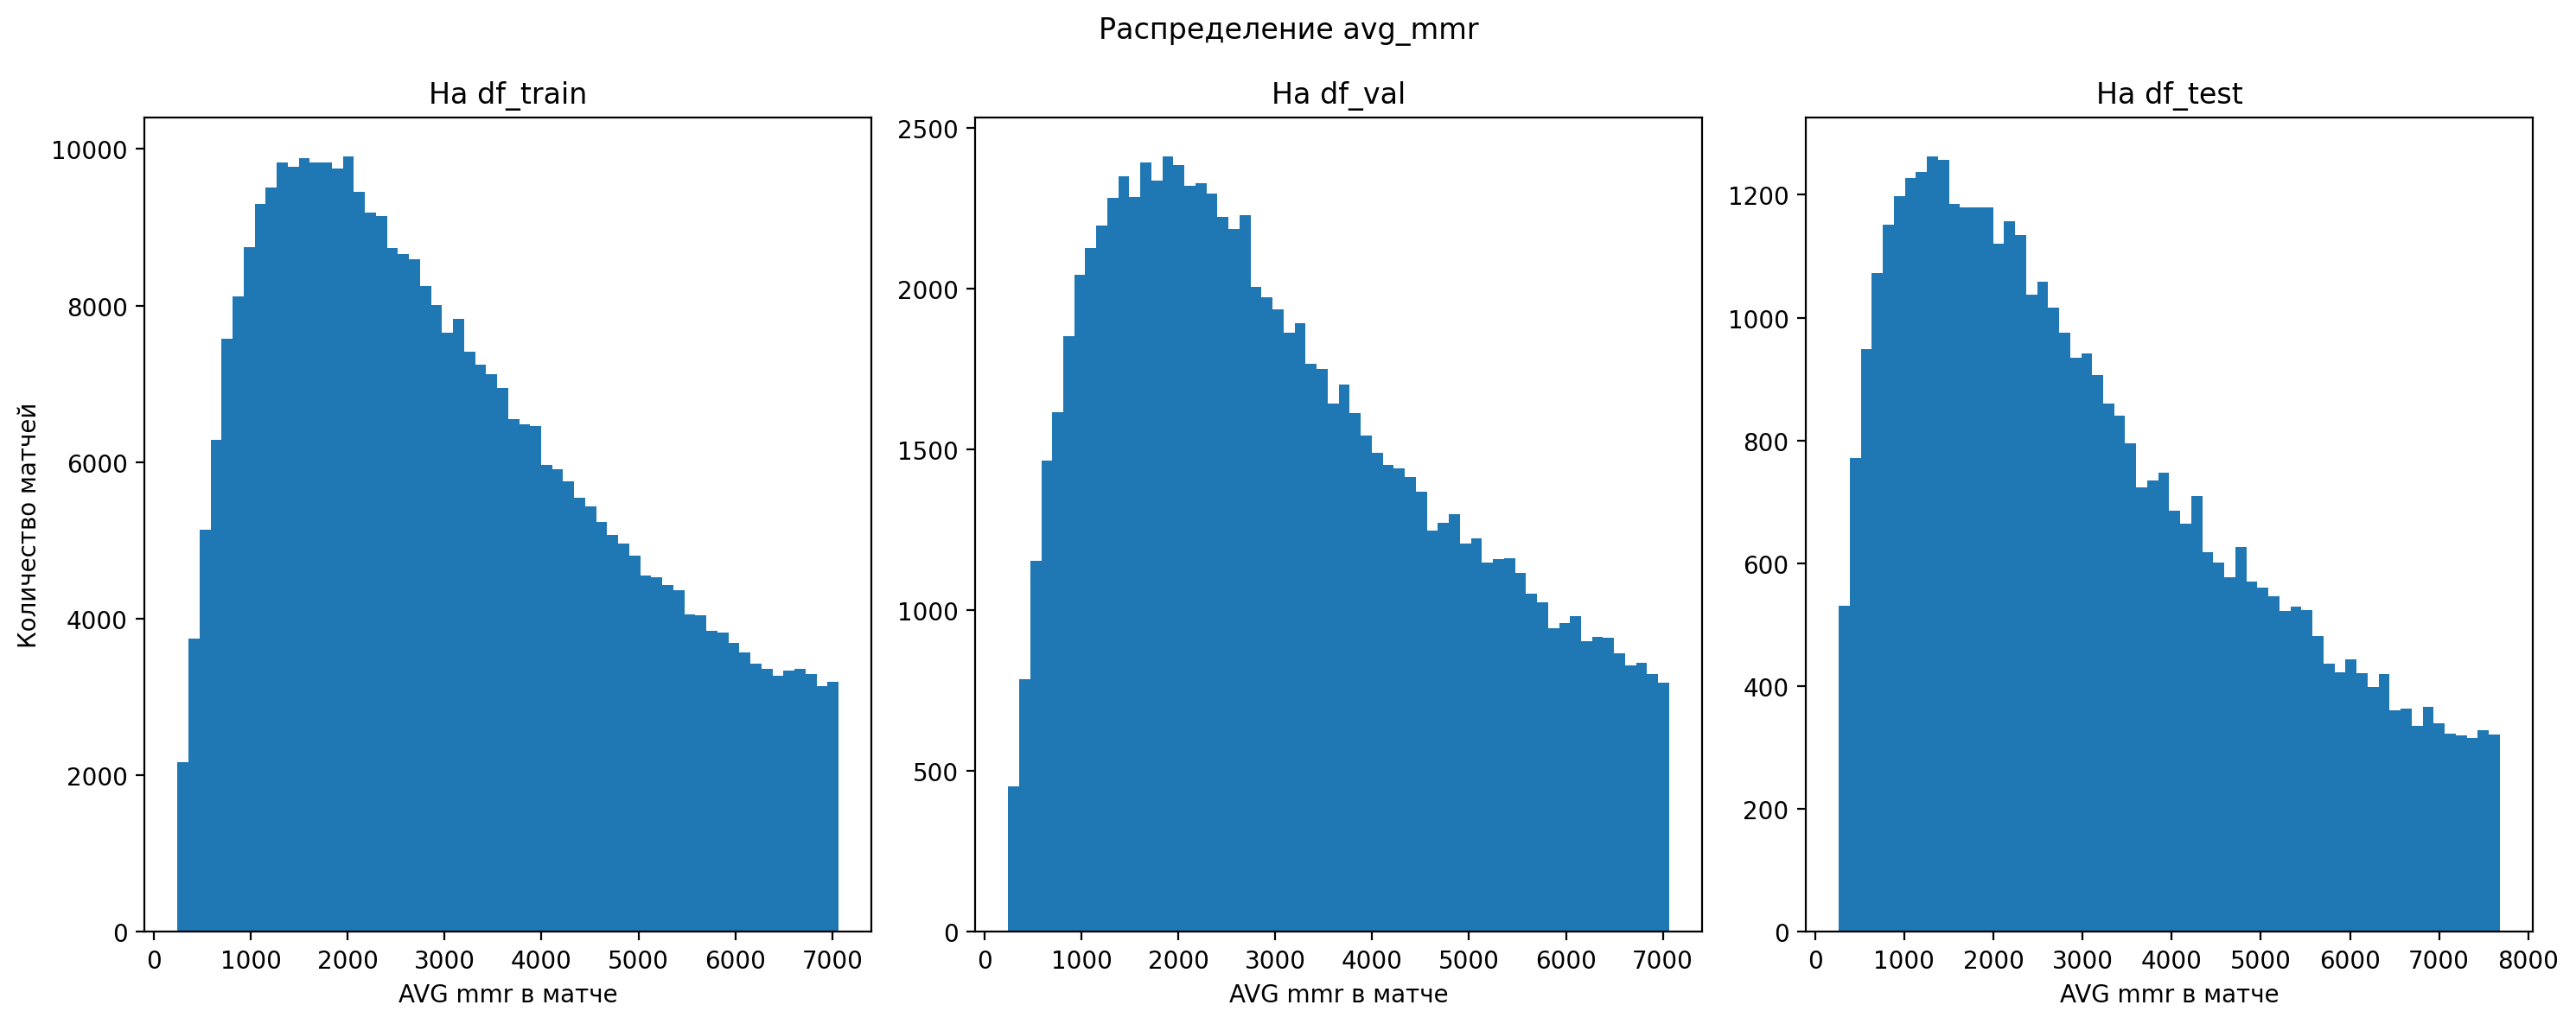

In [28]:
plt.figure(figsize=(12, 6))
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

fig.suptitle("Распределение avg_mmr")

axes[0].hist(df_train_oot["avg_mmr"], bins=60)
axes[0].set_title("На df_train")
axes[0].set_xlabel("AVG mmr в матче")
axes[0].set_ylabel("Количество матчей")

axes[1].hist(df_val_oot["avg_mmr"], bins=60)
axes[1].set_title("На df_val")
axes[1].set_xlabel("AVG mmr в матче")

axes[2].hist(df_test["avg_mmr"], bins=60)
axes[2].set_title("На df_test")
axes[2].set_xlabel("AVG mmr в матче")

plt.tight_layout()
plt.show();

Распределения визуально очень похожи друг на друга, а еще они очень похожи на Гамма распределение. Не зря тервер на 10.

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:** Распределение хорошее, нет выбросов, они похожи друг на друга в трейне, вале и тесте. Похожи все на Гамма-распределение или на какое-то близ к экспоненциальному.

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но на практике это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

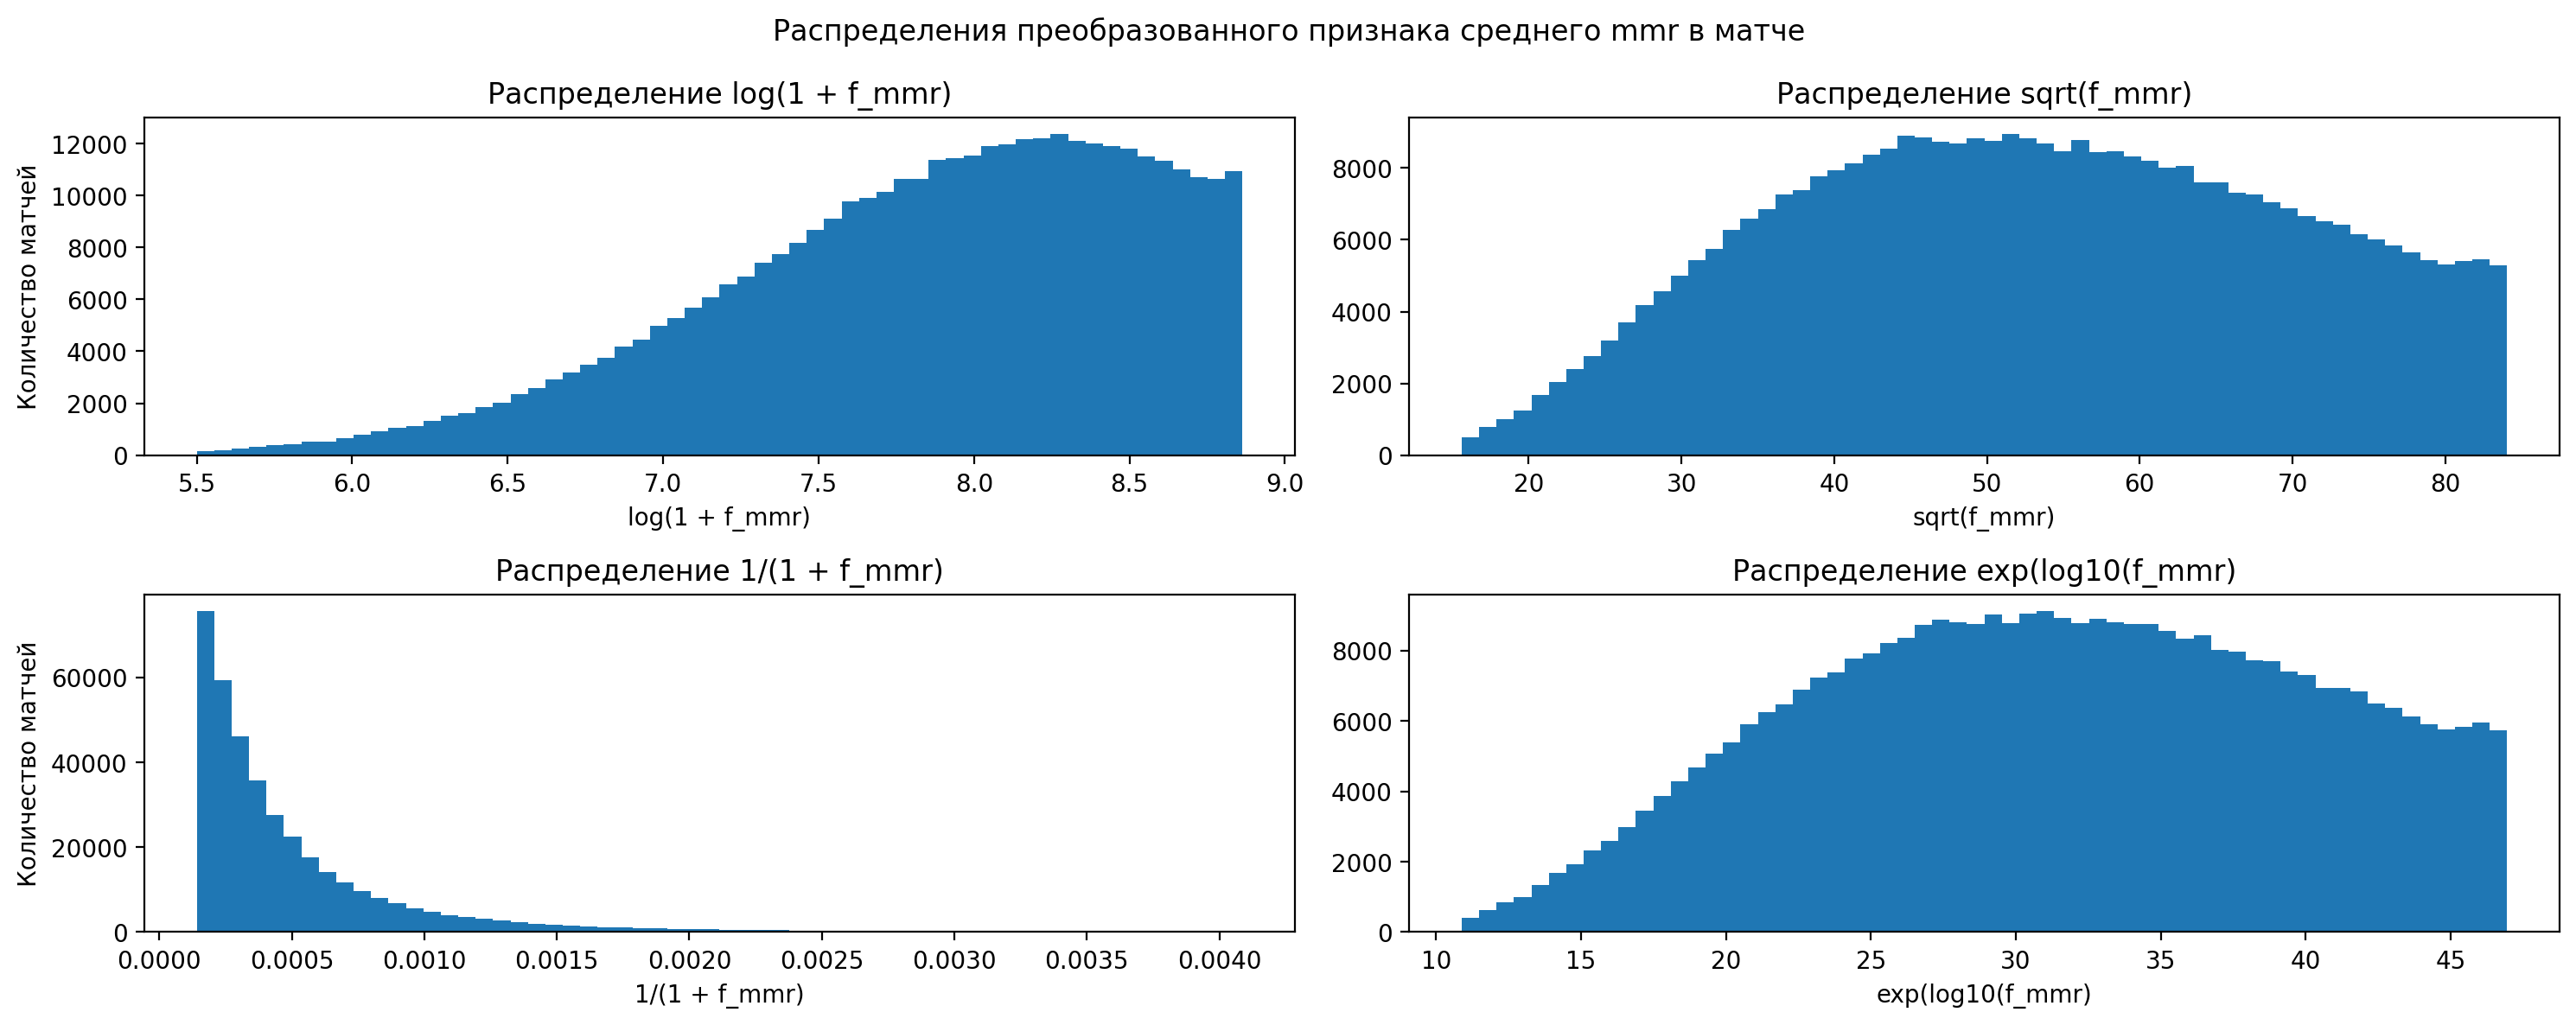

In [29]:
df_train_oot["avg_mmr_log1p"] = np.log1p(df_train_oot["avg_mmr"])
df_train_oot["avg_mmr_sqrt"] = np.sqrt(df_train_oot["avg_mmr"])
df_train_oot["avg_mmr_sig"] = 1/(1 + df_train_oot["avg_mmr"])
df_train_oot["avg_mmr_exp"] = np.exp(np.log10(df_train_oot["avg_mmr"]))


fig, axes = plt.subplots(2, 2, figsize=(15, 6))
fig.suptitle("Распределения преобразованного признака среднего mmr в матче")

axes[0, 0].hist(df_train_oot["avg_mmr_log1p"], bins=60)
axes[0, 0].set_title("Распределение log(1 + f_mmr)")
axes[0, 0].set_ylabel("Количество матчей")
axes[0, 0].set_xlabel("log(1 + f_mmr)")


axes[0, 1].hist(df_train_oot["avg_mmr_sqrt"], bins=60)
axes[0, 1].set_title("Распределение sqrt(f_mmr)")

axes[0, 1].set_xlabel("sqrt(f_mmr)")


axes[1, 0].hist(df_train_oot["avg_mmr_sig"], bins=60)
axes[1, 0].set_title("Распределение 1/(1 + f_mmr)")
axes[1, 0].set_ylabel("Количество матчей")
axes[1, 0].set_xlabel("1/(1 + f_mmr)")


axes[1, 1].hist(df_train_oot["avg_mmr_exp"], bins=60)
axes[1, 1].set_title("Распределение exp(log10(f_mmr)")
axes[1, 1].set_xlabel("exp(log10(f_mmr)")

plt.tight_layout()


Ну мы ищем, что лучше всего подходит для нормального распределение, но корень как преобразование так себе, а $\exp\log$ ваще непонятно что, поэтому возьмем проверенный временем и народом $\log(1 + p)$

In [30]:
df_train["avg_mmr_log"] = np.log1p(df_train["avg_mmr"])
df_test["avg_mmr_log"] = np.log1p(df_test["avg_mmr"])

Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#d18753">**Можете**</font> замерить его влияние, если есть желание, может это полная дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** Нулем в нашем случае такое себе заполнять, потому что распределение признака станет двумодальным, потому что пропусков ай как много, что не есть приятно, лучше заполним средним или медианной.

</div>

In [31]:
df_train["mmr_missing"] = df_train["avg_mmr"].apply(lambda x: 1 if pd.isna(x) else 0)
df_test["mmr_missing"] = df_test["avg_mmr"].apply(lambda x: 1 if pd.isna(x) else 0)

Заполним пропуски в $\text{avg mmr}$ медианой.

In [32]:
mmr_median = df_train["avg_mmr"].median()
mmr_log_median = df_train["avg_mmr_log"].median()


df_train["avg_mmr"] = df_train["avg_mmr"].fillna(mmr_median)
df_test["avg_mmr"] = df_test["avg_mmr"].fillna(mmr_median)

df_train["avg_mmr_log"] = df_train["avg_mmr_log"].fillna(mmr_log_median)
df_test["avg_mmr_log"] = df_test["avg_mmr_log"].fillna(mmr_log_median)

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на тесте

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на тесте \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [33]:
features_ = ['game_mode', 'avg_mmr',
       'region_Europe West', 'region_South Africa', 'region_SE Asia',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', "mmr_missing"]
# 'is_weekend', 'days_last_patch'
model = LogisticRegression(max_iter=10000, tol=1e-3)

mean_gini, scores = CV_OOT(model, features_)
print(mean_gini)
scores

0.14669927198869262


[0.1494239354691258,
 0.14610217692684402,
 0.14763269166267534,
 0.1455755268120964,
 0.14462746535686644,
 0.14912095285613525,
 0.14441215483710512]

In [34]:
features_ = ['game_mode', 'avg_mmr_log',
       'region_Europe West', 'region_South Africa', 'region_SE Asia',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', "mmr_missing"]
# 'is_weekend', 'days_last_patch'

model = LogisticRegression(max_iter=10000, tol=1e-3)

mean_gini, scores = CV_OOT(model, features_)
print(mean_gini)
scores

0.14891193576008402


[0.1523712675308051,
 0.14779532871100964,
 0.14987864277226004,
 0.14924202615561866,
 0.14643871613258064,
 0.15042539886888084,
 0.14623217014943313]

### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [35]:
players_df = pd.read_csv("data/player_df.csv")
heroes_df = pd.read_csv("data/Constants.Heroes.csv")

In [36]:
players_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7650825 entries, 0 to 7650824
Data columns (total 14 columns):
 #   Column        Dtype  
---  ------        -----  
 0   player_slot   int64  
 1   account_id    int64  
 2   hero_id       int64  
 3   kills         float64
 4   deaths        float64
 5   assists       float64
 6   gold          float64
 7   last_hits     float64
 8   denies        float64
 9   gold_per_min  float64
 10  xp_per_min    float64
 11  hero_damage   float64
 12  tower_damage  float64
 13  match_id      int64  
dtypes: float64(10), int64(4)
memory usage: 817.2 MB


In [37]:
players_df[players_df["account_id"] < 0]

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
153,1,-1,44,15.0,14.0,6.0,1146.0,99.0,23.0,472.0,678.0,20610.0,258.0,519759
208,129,-1,99,2.0,6.0,0.0,441.0,32.0,0.0,230.0,249.0,3236.0,0.0,380288
266,0,-1,26,4.0,6.0,10.0,1668.0,20.0,8.0,251.0,387.0,7626.0,135.0,78412
468,130,-1,35,1.0,11.0,6.0,493.0,37.0,16.0,225.0,226.0,3405.0,0.0,139264
710,0,-1,32,19.0,1.0,9.0,1422.0,73.0,0.0,397.0,455.0,20446.0,240.0,483564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7649692,131,-1,37,1.0,5.0,4.0,515.0,44.0,21.0,243.0,306.0,3212.0,402.0,411972
7649905,129,-1,32,11.0,4.0,14.0,544.0,105.0,19.0,520.0,667.0,18080.0,650.0,258567
7650128,128,-1,30,9.0,13.0,5.0,271.0,13.0,9.0,258.0,216.0,11769.0,0.0,493065
7650410,129,-1,99,1.0,13.0,7.0,600.0,51.0,0.0,223.0,216.0,6096.0,49.0,484493


Ну вот видимо значением -1 помечены особым данные, которые собраны некорректно.

In [38]:
players_df[players_df["account_id"] == 4294967295]

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
10,128,4294967295,71,36.0,15.0,15.0,2742.0,76.0,4.0,538.0,645.0,34688.0,1177.0,251954
18,2,4294967295,65,2.0,10.0,9.0,277.0,98.0,1.0,326.0,386.0,6117.0,272.0,738147
20,128,4294967295,7,14.0,13.0,17.0,1846.0,251.0,0.0,361.0,474.0,22276.0,183.0,474296
25,128,4294967295,15,4.0,9.0,4.0,311.0,79.0,3.0,302.0,350.0,10442.0,88.0,242554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650816,4,4294967295,49,3.0,5.0,8.0,3003.0,56.0,0.0,375.0,294.0,6399.0,2000.0,585273
7650818,131,4294967295,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,196312
7650819,4,4294967295,95,12.0,11.0,9.0,1679.0,349.0,33.0,520.0,483.0,20825.0,2969.0,226515
7650820,4,4294967295,63,16.0,9.0,10.0,467.0,152.0,5.0,494.0,619.0,24378.0,1700.0,400075


А также большая часть датасета размечена с айдишником $4294967295$, что тоже заставляет задуматься, один человек врядли мог бы сыграть 2,8 млн игр за год...

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** Ну если их немного, то наверное можем без особого ущерба, ведь матчей у нас ух как много.

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [39]:
valid = players_df.groupby("match_id")["hero_id"].count()
valid[valid > 10]

match_id
363279    20
Name: hero_id, dtype: int64

In [40]:
valid = valid[valid == 10].index
players_df = players_df[players_df["match_id"].isin(valid)]

Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [41]:
zeros = players_df[players_df["hero_id"] == 0]["match_id"].unique()
players_df = players_df[~players_df["match_id"].isin(zeros)]
players_df = players_df.dropna(subset=["hero_id", "player_slot"])
players_df[players_df["hero_id"] == 0]

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id


In [42]:
players_df.isna().sum()

player_slot          0
account_id           0
hero_id              0
kills           605950
deaths          605950
assists         605950
gold            605950
last_hits       605950
denies          605950
gold_per_min    605950
xp_per_min      605950
hero_damage     605950
tower_damage    605950
match_id             0
dtype: int64

In [43]:
rad = [0, 1, 2, 3, 4]
dir = [128, 129, 130, 131, 132]

radiant = players_df[(players_df["player_slot"].isin(rad)) & (~players_df["account_id"].isin([-1, 4294967295]))][["match_id", "account_id"]]
dire = players_df[players_df["player_slot"].isin(dir) & (~players_df["account_id"].isin([-1, 4294967295]))][["match_id", "account_id"]]

in_match = radiant.merge(dire, on=["match_id", "account_id"])
bad_match = in_match["match_id"].unique()

players_df = players_df[~players_df["match_id"].isin(bad_match)]
players_df

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650820,4,4294967295,63,16.0,9.0,10.0,467.0,152.0,5.0,494.0,619.0,24378.0,1700.0,400075
7650821,0,4294967295,95,8.0,11.0,13.0,9.0,183.0,4.0,449.0,544.0,13792.0,4817.0,465077
7650822,3,122912707,36,6.0,3.0,18.0,1078.0,74.0,8.0,334.0,336.0,7769.0,533.0,571444
7650823,0,104518723,87,4.0,11.0,9.0,1017.0,18.0,4.0,219.0,218.0,4087.0,91.0,234954


Сначала забыл сделать еще условие, что это не спец айди и половина записей затерлась -_-, пришлось в панике осозновать че сделал не так...

In [44]:
all_match = pd.concat([df_train["match_id"], df_test["match_id"]])
players_df = players_df[players_df["match_id"].isin(all_match)]
players_df

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795
5,0,33392751,112,9.0,7.0,10.0,718.0,111.0,4.0,357.0,342.0,7537.0,591.0,457685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650820,4,4294967295,63,16.0,9.0,10.0,467.0,152.0,5.0,494.0,619.0,24378.0,1700.0,400075
7650821,0,4294967295,95,8.0,11.0,13.0,9.0,183.0,4.0,449.0,544.0,13792.0,4817.0,465077
7650822,3,122912707,36,6.0,3.0,18.0,1078.0,74.0,8.0,334.0,336.0,7769.0,533.0,571444
7650823,0,104518723,87,4.0,11.0,9.0,1017.0,18.0,4.0,219.0,218.0,4087.0,91.0,234954


In [45]:
radiant = players_df[players_df["player_slot"].isin(rad)].groupby("match_id")["player_slot"].count()
dire_ = players_df[players_df["player_slot"].isin(dir)].groupby("match_id")["player_slot"].count()

print((radiant != 5).sum())
print((dire_ != 5).sum())

0
0


фуууух...

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#d18753">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#d18753">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [46]:
from scipy.sparse import csr_array  # вам может понравиться

class HeroesEncoder:

    def fit(self, X, y=None):
        # Мы как бы говорим, какие герои будут в наших данных(если мы будем делать на батчах, то эт важно)
        self.heroes_ = [f"hero_{h}" for h in sorted(X["hero_id"].unique())]
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X["team"] = X["player_slot"].apply(lambda x: 1 if x in range(5) else -1)
        matrix  = X.pivot_table(index="match_id", columns="hero_id", values="team", fill_value=0)
        matrix.columns = [f"hero_{col}" for col in matrix.columns]
        matrix = matrix.reindex(columns=self.heroes_, fill_value=0)
        return matrix
        raise Exception("transform method not implemented")

In [47]:
heroes_encoder = HeroesEncoder()
heroes_encoder.fit(players_df)
vec = heroes_encoder.transform(players_df)
vec

,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,hero_7,hero_8,hero_9,hero_10,...,hero_102,hero_103,hero_104,hero_105,hero_106,hero_107,hero_109,hero_110,hero_111,hero_112
match_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767816,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
767817,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
767818,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.0,0.0,0.0,-1.0,1.0,0.0,0.0


In [48]:
vec["hero_1"].sum()

np.float64(-970.0)

Черт, антимаг больше ценится в команде Dire, причем сильно так.

Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [49]:
df_train.columns

Index(['match_id', 'date', 'game_mode', 'duration', 'radiant_win', 'avg_mmr',
       'region_Europe West', 'region_South Africa', 'region_SE Asia',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'is_weekend', 'days_last_patch', 'avg_mmr_log',
       'mmr_missing'],
      dtype='str')

In [50]:
df_train = df_train.set_index("match_id").join(vec).reset_index()
hero_col = vec.columns.to_list()
df_train[hero_col] = df_train[hero_col].fillna(0)

In [51]:
df_test = df_test.set_index("match_id").join(vec).reset_index()

In [52]:
df_test[hero_col] = df_test[hero_col].fillna(0)

Еще я заметил, что мы никак не закодировали признак $\text{game mode}$, давайте его тоже заOHEшим

In [53]:
df_train["game_mode"] = df_train["game_mode"].astype(str)
df_test["game_mode"] = df_test["game_mode"].astype(str)

In [54]:
encoder = ce.OneHotEncoder(use_cat_names=True)
game_mode_train = encoder.fit_transform(df_train["game_mode"])
game_mode_test = encoder.transform(df_test["game_mode"])

df_train = pd.concat([df_train.drop("game_mode", axis=1).reset_index(drop=True), game_mode_train.reset_index(drop=True)], axis=1)
df_test = pd.concat([df_test.drop("game_mode", axis=1).reset_index(drop=True), game_mode_test.reset_index(drop=True)], axis=1)

In [ ]:
features = vec.columns.tolist()
model_heroes = LogisticRegression(max_iter=10000)
mean_gini_heroes, scores_heroes = CV_OOT(model_heroes, feature_cols=features)
print(mean_gini_heroes)
scores_heroes

0.26966590854258


[0.26862479210689827,
 0.2779199929975813,
 0.2673725816851338,
 0.26972665518110706,
 0.2646187480787263,
 0.2684047435008108,
 0.2709938462478023]

Попробуем SGDClassfier, просто из интереса.

In [56]:
features = vec.columns.tolist()
model_heroes = SGDClassifier(loss="log_loss", penalty="elasticnet", max_iter=10000, l1_ratio=0.22)
mean_gini_heroes, scores_heroes = CV_OOT(model_heroes, feature_cols=features)
print(mean_gini_heroes)
scores_heroes

0.26375703422673763


[0.26001621989220713,
 0.27149108140136247,
 0.25826132367165844,
 0.26555706766822773,
 0.25996503266491633,
 0.2641309343233451,
 0.26687757996544637]

эх, сейчас бы прописать просто DEVICE = "mps" if torch.backends.mps.is_available() else "cpu", и не ждать 5 минут для обучения... CUDA ядер нет на локалке к сожалению, так бы конечно DEVICE = "cuda" if torch.cuda.availible()

In [57]:
minus = ["date", "duration", "radiant_win", "match_id", "avg_mmr"]
features = [col for col in df_train.columns if col not in minus]

model_clf = SGDClassifier(loss="log_loss", penalty="elasticnet", max_iter=10000, l1_ratio=0.3)
mean_gini, scores = CV_OOT(model_clf, features)
print(mean_gini)
scores

0.3013494193156157


[0.30011484216410755,
 0.3062902047489233,
 0.2988629866172088,
 0.30203599133505854,
 0.29633738001759147,
 0.30117078265136477,
 0.3046337476750558]

In [ ]:
all_model = LogisticRegression(max_iter=10000)
mean_gini, scores = CV_OOT(all_model, features)
print(mean_gini)
scores

0.3049119415405818


[0.3057556587937631,
 0.3083529337174806,
 0.30396308489857526,
 0.30528916158241115,
 0.2995986130551471,
 0.30463740890399627,
 0.3067867298326994]

In [59]:
all_model.fit(df_train[features], df_train["radiant_win"])
model_clf.fit(df_train[features], df_train["radiant_win"])

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'elasticnet'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.3
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",10000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [60]:
minus = ["avg_mmr", "date", "match_id"]
features = [col for col in df_test.columns if col not in minus]


y_pred_log = all_model.predict_proba(df_test[features])[:, 1]
y_pred_log

array([0.38803006, 0.62042659, 0.61175532, ..., 0.30713417, 0.6088119 ,
       0.61930008], shape=(59748,))

In [61]:
y_pred_clf = model_clf.predict_proba(df_test[features])[:, 1]
y_pred_clf

array([0.35336316, 0.55130601, 0.55719932, ..., 0.26714463, 0.54264301,
       0.56229936], shape=(59748,))

In [62]:
prediction = pd.DataFrame(columns=["ID", "Value"])
prediction["ID"] = df_test["match_id"]
prediction["Value"] = y_pred_log
prediction.to_csv("data/log_prediction.csv", index=False, encoding="utf8")

In [63]:
prediction = pd.DataFrame(columns=["ID", "Value"])
prediction["ID"] = df_test["match_id"]
prediction["Value"] = y_pred_clf
prediction.to_csv("data/clf_prediction.csv", index=False, encoding="utf8")

Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняет данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#d18753">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать их со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. \
<font color="#d18753">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#d18753"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \
Выбор, как всегда, в ваших руках.

</div>

In [88]:
minus_train = ["date", "duration", "radiant_win", "match_id", "avg_mmr"]
minus_test = ["date", "match_id", "avg_mmr"]

features_train = [col for col in df_train.columns if col not in minus_train]
features_test = [col for col in df_test.columns if col not in minus_test]

In [ ]:
import optuna


def objective(trial):
    # model parameters
    params = {
        "C" : trial.suggest_float("C", 1e-5, 1e3, log=True),
        "solver" : trial.suggest_categorical("solver", ["lbfgs", "liblinear"]),
        "max_iter" : 10000
    }
    model = LogisticRegression(**params)
    mean_gini, _ = CV_OOT(model, features_train)
    gini_valid = mean_gini
    
    return gini_valid




study_log = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study_log.optimize(objective, show_progress_bar=True, n_trials=25)

[I 2026-03-09 11:49:20,594] A new study created in memory with name: no-name-2d252727-8b7f-461f-b158-2cc654c5723e
Best trial: 0. Best value: 0.304953:   4%|▍         | 1/25 [00:18<07:32, 18.86s/it]

[I 2026-03-09 11:49:39,455] Trial 0 finished with value: 0.30495316956517177 and parameters: {'C': 0.3240808674703243, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.30495316956517177.


Best trial: 0. Best value: 0.304953:   8%|▊         | 2/25 [00:26<04:36, 12.01s/it]

[I 2026-03-09 11:49:46,662] Trial 1 finished with value: 0.27108875081360195 and parameters: {'C': 2.0153909664485057e-05, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.30495316956517177.


Best trial: 0. Best value: 0.304953:  12%|█▏        | 3/25 [00:44<05:28, 14.95s/it]

[I 2026-03-09 11:50:05,110] Trial 2 finished with value: 0.30493569432616446 and parameters: {'C': 0.5584825418918203, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.30495316956517177.


Best trial: 3. Best value: 0.304956:  16%|█▌        | 4/25 [00:55<04:43, 13.52s/it]

[I 2026-03-09 11:50:16,444] Trial 3 finished with value: 0.3049560826247136 and parameters: {'C': 0.17967292800109533, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  20%|██        | 5/25 [01:09<04:31, 13.60s/it]

[I 2026-03-09 11:50:30,176] Trial 4 finished with value: 0.3049505765947166 and parameters: {'C': 8.58721605083243, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  24%|██▍       | 6/25 [01:15<03:26, 10.85s/it]

[I 2026-03-09 11:50:35,706] Trial 5 finished with value: 0.2900229649332597 and parameters: {'C': 0.00013443552971527682, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  28%|██▊       | 7/25 [01:29<03:33, 11.85s/it]

[I 2026-03-09 11:50:49,607] Trial 6 finished with value: 0.30495100259786007 and parameters: {'C': 11.533687950186879, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  32%|███▏      | 8/25 [01:43<03:33, 12.55s/it]

[I 2026-03-09 11:51:03,649] Trial 7 finished with value: 0.3049505009476731 and parameters: {'C': 8.05508291862506, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  36%|███▌      | 9/25 [02:00<03:45, 14.09s/it]

[I 2026-03-09 11:51:21,119] Trial 8 finished with value: 0.304941579240345 and parameters: {'C': 0.04639392673049232, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  40%|████      | 10/25 [02:07<02:58, 11.89s/it]

[I 2026-03-09 11:51:28,075] Trial 9 finished with value: 0.3031848821259996 and parameters: {'C': 0.0022379992099332805, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  44%|████▍     | 11/25 [02:23<03:05, 13.25s/it]

[I 2026-03-09 11:51:44,410] Trial 10 finished with value: 0.3049522706778029 and parameters: {'C': 404.7446509945461, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  48%|████▊     | 12/25 [02:42<03:13, 14.87s/it]

[I 2026-03-09 11:52:02,999] Trial 11 finished with value: 0.30493409035573676 and parameters: {'C': 0.030898694739135747, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  52%|█████▏    | 13/25 [03:00<03:11, 15.99s/it]

[I 2026-03-09 11:52:21,568] Trial 12 finished with value: 0.30492350831476517 and parameters: {'C': 0.3873699338851895, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  56%|█████▌    | 14/25 [03:20<03:08, 17.11s/it]

[I 2026-03-09 11:52:41,257] Trial 13 finished with value: 0.3048959026142108 and parameters: {'C': 0.003971866818713726, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  60%|██████    | 15/25 [03:33<02:38, 15.88s/it]

[I 2026-03-09 11:52:54,292] Trial 14 finished with value: 0.3049510338405996 and parameters: {'C': 1.0886168511175098, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  64%|██████▍   | 16/25 [03:52<02:30, 16.68s/it]

[I 2026-03-09 11:53:12,825] Trial 15 finished with value: 0.3049523725517548 and parameters: {'C': 637.8607754811578, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  68%|██████▊   | 17/25 [03:59<01:51, 13.94s/it]

[I 2026-03-09 11:53:20,405] Trial 16 finished with value: 0.30451466890414913 and parameters: {'C': 0.006110617622048344, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  72%|███████▏  | 18/25 [04:18<01:46, 15.28s/it]

[I 2026-03-09 11:53:38,805] Trial 17 finished with value: 0.30494452483175755 and parameters: {'C': 27.512781678173873, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  76%|███████▌  | 19/25 [04:23<01:14, 12.38s/it]

[I 2026-03-09 11:53:44,422] Trial 18 finished with value: 0.2981682383166042 and parameters: {'C': 0.00048207526100007317, 'solver': 'liblinear'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 3. Best value: 0.304956:  80%|████████  | 20/25 [04:41<01:10, 14.09s/it]

[I 2026-03-09 11:54:02,492] Trial 19 finished with value: 0.3049507113002852 and parameters: {'C': 0.1091719879336463, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.3049560826247136.


Best trial: 20. Best value: 0.304959:  84%|████████▍ | 21/25 [05:00<01:01, 15.38s/it]

[I 2026-03-09 11:54:20,890] Trial 20 finished with value: 0.3049586603093276 and parameters: {'C': 101.08719133521973, 'solver': 'lbfgs'}. Best is trial 20 with value: 0.3049586603093276.


Best trial: 20. Best value: 0.304959:  88%|████████▊ | 22/25 [05:19<00:49, 16.41s/it]

[I 2026-03-09 11:54:39,686] Trial 21 finished with value: 0.3049349705669093 and parameters: {'C': 102.00184004951933, 'solver': 'lbfgs'}. Best is trial 20 with value: 0.3049586603093276.


Best trial: 20. Best value: 0.304959:  92%|█████████▏| 23/25 [05:38<00:34, 17.19s/it]

[I 2026-03-09 11:54:58,711] Trial 22 finished with value: 0.304927105836661 and parameters: {'C': 1.6542022844630555, 'solver': 'lbfgs'}. Best is trial 20 with value: 0.3049586603093276.


Best trial: 20. Best value: 0.304959:  96%|█████████▌| 24/25 [05:55<00:17, 17.13s/it]

[I 2026-03-09 11:55:15,703] Trial 23 finished with value: 0.30493042902731865 and parameters: {'C': 0.1930619618587701, 'solver': 'lbfgs'}. Best is trial 20 with value: 0.3049586603093276.


Best trial: 20. Best value: 0.304959: 100%|██████████| 25/25 [06:13<00:00, 14.93s/it]

[I 2026-03-09 11:55:33,895] Trial 24 finished with value: 0.3049200951405326 and parameters: {'C': 0.015708870177509382, 'solver': 'lbfgs'}. Best is trial 20 with value: 0.3049586603093276.


In [ ]:
def objective(trial):
    # model parameters
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    params = {
        "alpha": trial.suggest_float("alpha", 1e-5, 1e3, log=True),
        "loss": trial.suggest_categorical("loss", ["log_loss", "modified_huber"]),
        "max_iter": 10000,
        "penalty": penalty,
    }
    if penalty == "elasticnet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

    model = SGDClassifier(**params)
    mean_gini, _ = CV_OOT(model, features_train)
    gini_valid = mean_gini
    
    return gini_valid




study_sgd = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study_sgd.optimize(objective, show_progress_bar=True, n_trials=25)

[I 2026-03-09 11:55:34,000] A new study created in memory with name: no-name-7c3cf574-205b-4931-982a-07e0ddd01449
Best trial: 0. Best value: 0.0322828:   4%|▍         | 1/25 [00:09<03:53,  9.75s/it]

[I 2026-03-09 11:55:43,744] Trial 0 finished with value: 0.03228276884381409 and parameters: {'penalty': 'l2', 'alpha': 10.170871212935538, 'loss': 'modified_huber'}. Best is trial 0 with value: 0.03228276884381409.


Best trial: 0. Best value: 0.0322828:   8%|▊         | 2/25 [00:22<04:26, 11.57s/it]

[I 2026-03-09 11:55:56,588] Trial 1 finished with value: 0.0 and parameters: {'penalty': 'l1', 'alpha': 263.0037798167672, 'loss': 'log_loss'}. Best is trial 0 with value: 0.03228276884381409.


Best trial: 2. Best value: 0.301364:  12%|█▏        | 3/25 [00:41<05:24, 14.75s/it] 

[I 2026-03-09 11:56:15,130] Trial 2 finished with value: 0.30136397292664796 and parameters: {'penalty': 'l2', 'alpha': 0.0001151457804278133, 'loss': 'log_loss'}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 2. Best value: 0.301364:  16%|█▌        | 4/25 [00:54<04:54, 14.05s/it]

[I 2026-03-09 11:56:28,091] Trial 3 finished with value: 0.10231312025611294 and parameters: {'penalty': 'elasticnet', 'alpha': 0.022289322920513267, 'loss': 'log_loss', 'l1_ratio': 0.48652790550967506}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 2. Best value: 0.301364:  20%|██        | 5/25 [02:34<15:03, 45.19s/it]

[I 2026-03-09 11:58:08,493] Trial 4 finished with value: 0.28422793048443207 and parameters: {'penalty': 'l2', 'alpha': 2.82971470908531e-05, 'loss': 'modified_huber'}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 2. Best value: 0.301364:  24%|██▍       | 6/25 [02:46<10:41, 33.75s/it]

[I 2026-03-09 11:58:20,056] Trial 5 finished with value: 0.011357434417908152 and parameters: {'penalty': 'elasticnet', 'alpha': 4.170462732045444, 'loss': 'log_loss', 'l1_ratio': 0.031768639247390595}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 2. Best value: 0.301364:  28%|██▊       | 7/25 [02:56<07:49, 26.07s/it]

[I 2026-03-09 11:58:30,295] Trial 6 finished with value: 0.029305833163694537 and parameters: {'penalty': 'l2', 'alpha': 50.16848054780306, 'loss': 'modified_huber'}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 2. Best value: 0.301364:  32%|███▏      | 8/25 [03:08<06:10, 21.78s/it]

[I 2026-03-09 11:58:42,908] Trial 7 finished with value: 0.0 and parameters: {'penalty': 'elasticnet', 'alpha': 0.8059245038192254, 'loss': 'modified_huber', 'l1_ratio': 0.5612602038158975}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 2. Best value: 0.301364:  36%|███▌      | 9/25 [03:20<04:56, 18.56s/it]

[I 2026-03-09 11:58:54,374] Trial 8 finished with value: 0.0 and parameters: {'penalty': 'elasticnet', 'alpha': 79.86351015469106, 'loss': 'log_loss', 'l1_ratio': 0.17166289589838957}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 2. Best value: 0.301364:  40%|████      | 10/25 [04:56<10:36, 42.42s/it]

[I 2026-03-09 12:00:30,218] Trial 9 finished with value: 0.28740782592294895 and parameters: {'penalty': 'l2', 'alpha': 2.8931989667567503e-05, 'loss': 'modified_huber'}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 2. Best value: 0.301364:  44%|████▍     | 11/25 [05:09<07:50, 33.60s/it]

[I 2026-03-09 12:00:43,837] Trial 10 finished with value: 0.1704839704058608 and parameters: {'penalty': 'l1', 'alpha': 0.006183520868686039, 'loss': 'log_loss'}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 2. Best value: 0.301364:  48%|████▊     | 12/25 [07:38<14:51, 68.59s/it]

[I 2026-03-09 12:03:12,444] Trial 11 finished with value: 0.277332279122798 and parameters: {'penalty': 'l2', 'alpha': 1.199498207979208e-05, 'loss': 'modified_huber'}. Best is trial 2 with value: 0.30136397292664796.


Best trial: 12. Best value: 0.303639:  52%|█████▏    | 13/25 [07:51<10:21, 51.82s/it]

[I 2026-03-09 12:03:25,691] Trial 12 finished with value: 0.303639443917696 and parameters: {'penalty': 'l2', 'alpha': 0.0005356489053400243, 'loss': 'log_loss'}. Best is trial 12 with value: 0.303639443917696.


Best trial: 13. Best value: 0.304133:  56%|█████▌    | 14/25 [08:04<07:19, 39.96s/it]

[I 2026-03-09 12:03:38,251] Trial 13 finished with value: 0.3041331419001942 and parameters: {'penalty': 'l2', 'alpha': 0.000797908396113527, 'loss': 'log_loss'}. Best is trial 13 with value: 0.3041331419001942.


Best trial: 14. Best value: 0.304515:  60%|██████    | 15/25 [08:16<05:15, 31.57s/it]

[I 2026-03-09 12:03:50,353] Trial 14 finished with value: 0.3045151961698497 and parameters: {'penalty': 'l2', 'alpha': 0.0010004884014767972, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515:  64%|██████▍   | 16/25 [08:28<03:50, 25.64s/it]

[I 2026-03-09 12:04:02,234] Trial 15 finished with value: 0.30428214056156716 and parameters: {'penalty': 'l2', 'alpha': 0.0010969291447880448, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515:  68%|██████▊   | 17/25 [08:39<02:51, 21.46s/it]

[I 2026-03-09 12:04:13,960] Trial 16 finished with value: 0.0 and parameters: {'penalty': 'l1', 'alpha': 0.20366650854600574, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515:  72%|███████▏  | 18/25 [08:50<02:06, 18.09s/it]

[I 2026-03-09 12:04:24,227] Trial 17 finished with value: 0.30306201594533055 and parameters: {'penalty': 'l2', 'alpha': 0.005043956550633783, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515:  76%|███████▌  | 19/25 [09:02<01:38, 16.43s/it]

[I 2026-03-09 12:04:36,766] Trial 18 finished with value: 0.30403424702637116 and parameters: {'penalty': 'l2', 'alpha': 0.0007269700128622991, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515:  80%|████████  | 20/25 [09:16<01:17, 15.47s/it]

[I 2026-03-09 12:04:50,003] Trial 19 finished with value: 0.11219631986049958 and parameters: {'penalty': 'l1', 'alpha': 0.010809027310655368, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515:  84%|████████▍ | 21/25 [09:26<00:55, 13.83s/it]

[I 2026-03-09 12:05:00,023] Trial 20 finished with value: 0.2806817505476424 and parameters: {'penalty': 'l2', 'alpha': 0.1067704657112549, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515:  88%|████████▊ | 22/25 [09:38<00:40, 13.46s/it]

[I 2026-03-09 12:05:12,601] Trial 21 finished with value: 0.30399004993626644 and parameters: {'penalty': 'l2', 'alpha': 0.0007077547565570842, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515:  92%|█████████▏| 23/25 [09:55<00:29, 14.57s/it]

[I 2026-03-09 12:05:29,761] Trial 22 finished with value: 0.3022352012612653 and parameters: {'penalty': 'l2', 'alpha': 0.00015508554618006036, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515:  96%|█████████▌| 24/25 [10:06<00:13, 13.56s/it]

[I 2026-03-09 12:05:40,979] Trial 23 finished with value: 0.303998504975412 and parameters: {'penalty': 'l2', 'alpha': 0.0022904996493605333, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


Best trial: 14. Best value: 0.304515: 100%|██████████| 25/25 [10:17<00:00, 24.68s/it]

[I 2026-03-09 12:05:51,065] Trial 24 finished with value: 0.2935339924227538 and parameters: {'penalty': 'l2', 'alpha': 0.028550577629193632, 'loss': 'log_loss'}. Best is trial 14 with value: 0.3045151961698497.


#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

Невозможно изменить Название графика у optuna, поэтому вот график для LogReg

/var/folders/0g/rd6pf3cs48x88_b1fv828syr0000gn/T/ipykernel_1785/254221680.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study_log)


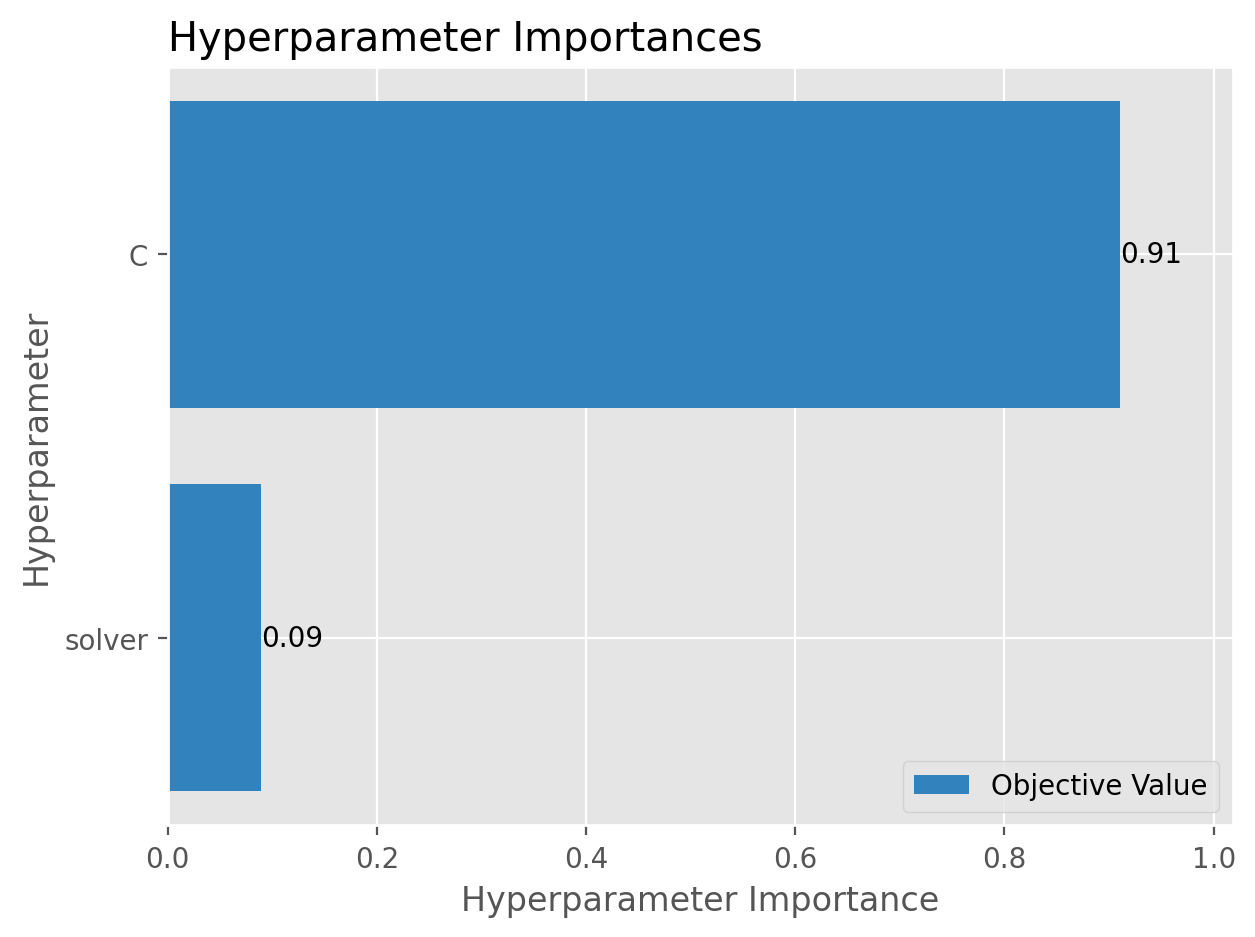

In [76]:
optuna.visualization.matplotlib.plot_param_importances(study_log)
# ax.set_title("Params importances for LogReg")
plt.tight_layout()
plt.show()

А вот график важности гиперпараметров у SGDClassifier

/var/folders/0g/rd6pf3cs48x88_b1fv828syr0000gn/T/ipykernel_1785/2073780535.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study_sgd)


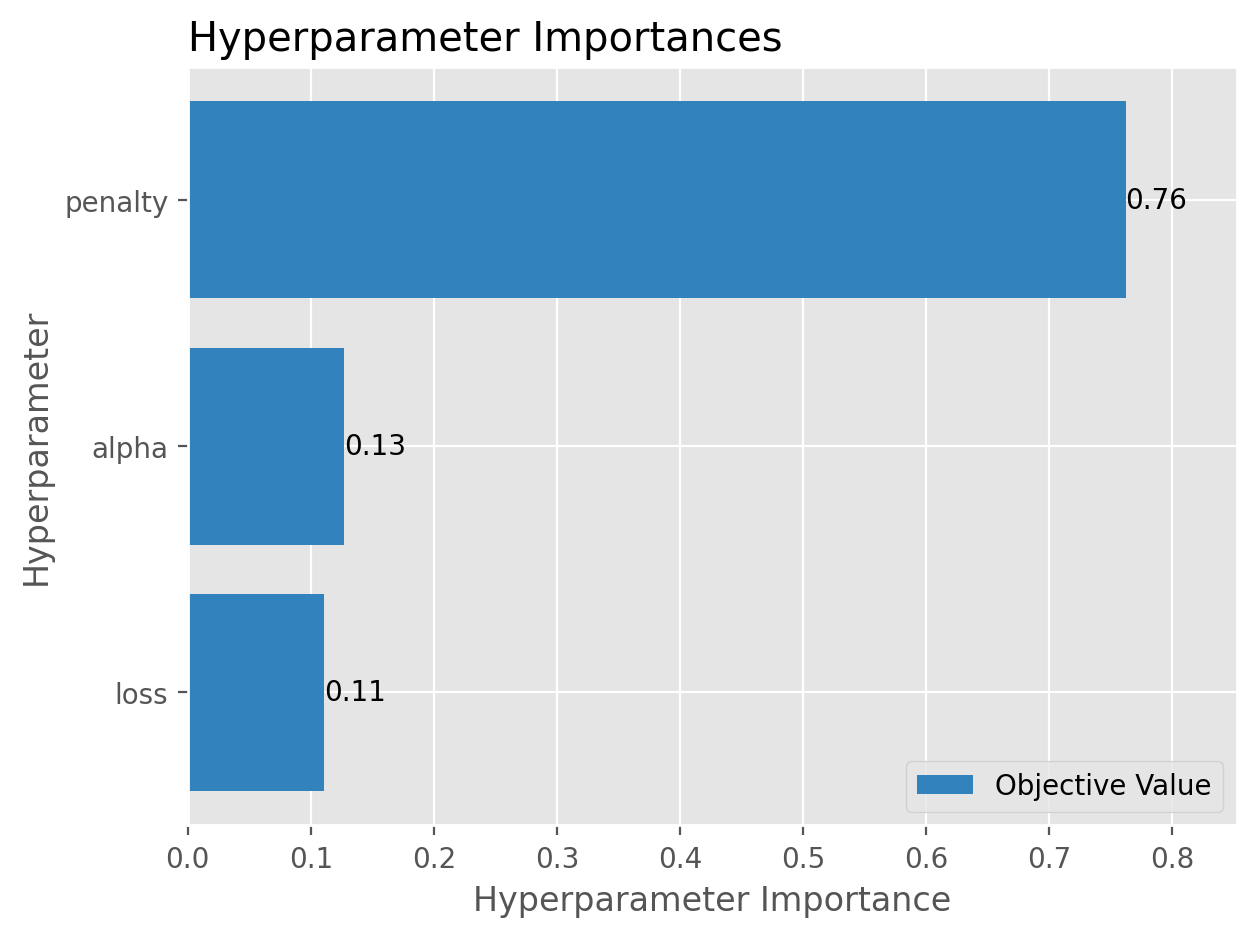

In [77]:
optuna.visualization.matplotlib.plot_param_importances(study_sgd)
# plt.title("Params importances for SGDClassifier")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:** Ну у Логистической регрессии самый важный параметр это коэффицент регуляризации $C$, а у SGDClassifier - это вид регуляризации, который мы исбираем.

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [85]:
df_train.to_csv("data/df_train_proc.csv", index=False)
df_test.to_csv("data/df_test_proc.csv", index=False)

In [89]:
best_params_optuna = {
    "C": 101.08719133521973, 
    "solver": "lbfgs",
    "max_iter": 10000
}

In [90]:
model_params = LogisticRegression(**best_params_optuna)
model_params.fit(df_train[features_train], df_train["radiant_win"])

y_pred = model_params.predict_proba(df_test[features_test])[:, 1]

prediction = pd.DataFrame(columns=["ID", "Value"])
prediction["ID"] = df_test["match_id"]
prediction["Value"] = y_pred
prediction.to_csv("data/log_base_prediction.csv", index=False, encoding="utf8")

In [91]:
def pipeline(model, params, features, filename):
    model = clone(model)
    model.fit(df_train[features], df_train["radiant_win"])

    y_pred = model.predict_proba(df_test[features])[:, 1]

    return y_pred